In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.signal import argrelmax
from matplotlib.collections import LineCollection
import re  
from matplotlib.lines import Line2D
import lmfit
from scipy.optimize import curve_fit
from lmfit import Model
import os
import re
import pandas as pd

%matplotlib widget
mpl.rcParams['font.family'] = 'serif'

In [2]:
def load_diel2(path, i, prefix="windeta-"):
    """ sdshfiuwrhsajhfwu"""
    
    file = f"{prefix}{i}.diel"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        if t_start_match and p_start_match:
            T = round(float(t_start_match.group(1)), 1)
            p = round(float(p_start_match.group(1)), 1)

    df = pd.read_csv(file_path, skiprows=5, delim_whitespace=True, header=0, names=["Freq. ","Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[5:-5]

    df['T'] = T
    df['p'] = p

    return df

def Isochrones(path, i):
    
    file = f"windeta-{i}.diel"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        if t_start_match and p_start_match:
            T = round(float(t_start_match.group(1)), 1)
            p = round(float(p_start_match.group(1)), 1)

    df = pd.read_csv(file_path, skiprows=5, delim_whitespace=True, header=0, names=["Freq. ","Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[5:-5]

    df['T'] = T
    df['p'] = p

    return df,file
    
def get_tau_max(df,permittivity, frequency,plot=False):

    nbors = 8
    idx0 = argrelmax(permittivity, order=nbors)[0][0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)

    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)

    if plot:
        
        pass

    rts = np.roots(np.polyder(p))
    fmax = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if fmax.imag != 0:
        raise RuntimeError("Imaginary root found!")

    fmax = fmax.real
    freq_scaled=frequency-fmax
    tau = 1 / fmax

    return tau



def Scaled_diel(df, permittivity, frequency, plot=False):
    nbors = 8
    idx0 = argrelmax(permittivity, order=nbors)[0][0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)
    
    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)

    # Evaluate the polynomial at fmax
    rts = np.roots(np.polyder(p))
    fmax = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if fmax.imag != 0:
        raise RuntimeError("Imaginary root found!")

    fmax = fmax.real
    
    permittivity_fmax = np.polyval(p, fmax)
    perm_scaled=permittivity/permittivity_fmax
    
    #idx_fmax = np.argmin(np.abs(frequency - fmax))         # it will give index of fmax
    freq_scaled = frequency / fmax
    
    #Permittivity_max = permittivity[idx_fmax]
    
    return freq_scaled, perm_scaled,fmax



def vft_equation(T, tau_v, D, T_v):
    return tau_v * np.exp(D * T_v / (T - T_v))


def lnvft(T, log10tau_v, D, T_v):
    return log10tau_v + (D /(T- T_v))


#path = '/net4/serdon/illdata/241/in16b/exp_6-02-645/rawdata/'
path = '/net4/serdon/illdata/242/in16b/exp_6-02-657/processed/Dielectric_data_all/'


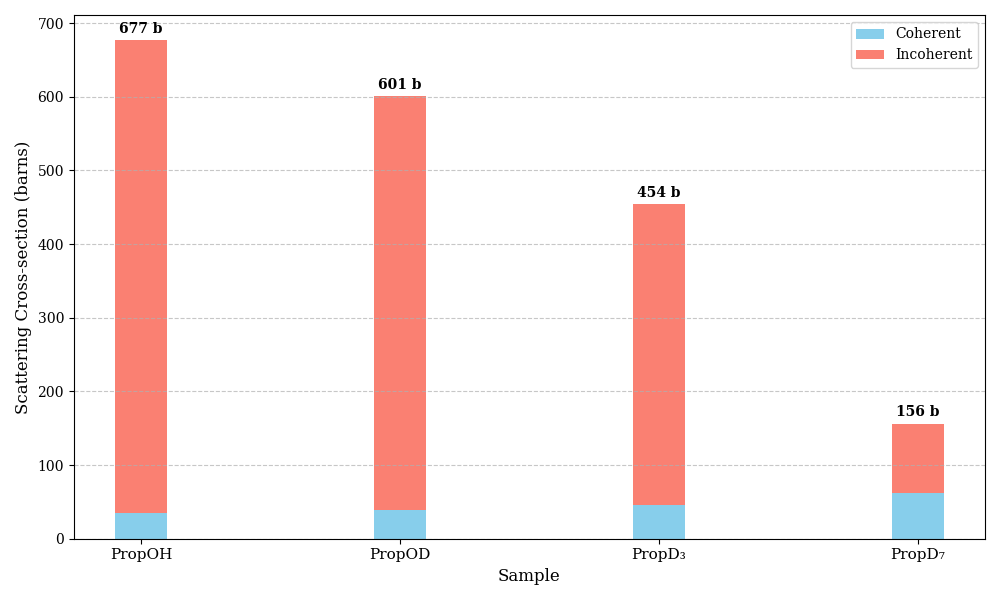

In [3]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget
mpl.rcParams['font.family'] = 'serif'

samples = ['PropOH', 'PropOD', 'PropD₃', 'PropD₇']


coherent = [34.96, 38.79, 46.45, 61.77]
incoherent = [642.16, 561.89, 407.50, 94.62]
total = [677.12, 600.68, 453.95, 156.39]


bar_width = 0.2
x = np.arange(len(samples))


fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, coherent, bar_width, label='Coherent', color='skyblue')
ax.bar(x, incoherent, bar_width, bottom=coherent, label='Incoherent', color='salmon')


for i in range(len(samples)):
    ax.text(x[i], total[i] + 10, f'{total[i]:.0f} b', ha='center', fontsize=10, weight='bold')


ax.set_ylabel('Scattering Cross-section (barns)', fontsize=12)
ax.set_xlabel('Sample', fontsize=12)
# ax.set_title('1-Propanol Isotopologues', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(samples, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/Simple_cell_propanol/Coherent_incoherent_histogram.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/Simple_cell_propanol/Coherent_incoherent_histogram.png',dpi=300)
plt.show()


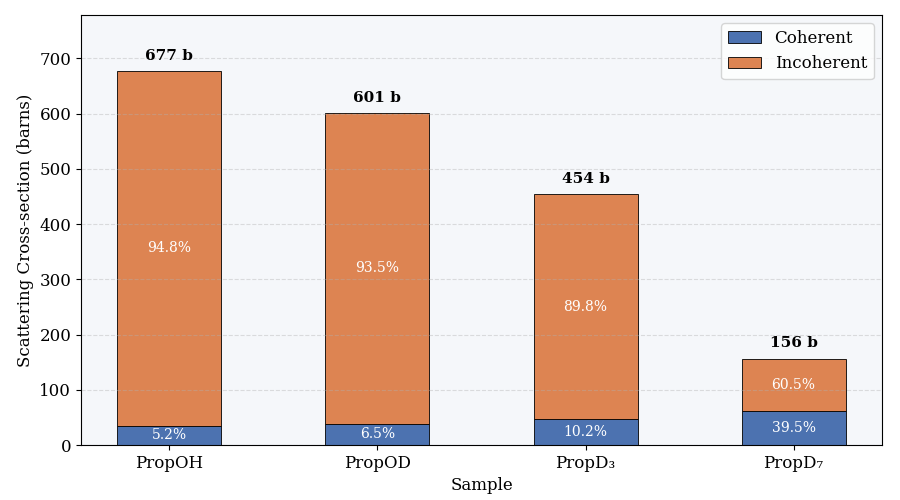

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

samples = ['PropOH', 'PropOD', 'PropD₃', 'PropD₇']


coherent = np.array([34.96, 38.79, 46.45, 61.77])
incoherent = np.array([642.16, 561.89, 407.50, 94.62])
total = coherent + incoherent

x = np.arange(len(samples))
bar_width = 0.5

fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.11, top=0.97, hspace=0.03)

# Colors 
coh_color = '#4C72B0'
inc_color = '#DD8452'

# Stacked bars
ax.bar(x, coherent, bar_width, label='Coherent',
       color=coh_color, edgecolor='black', linewidth=0.6)

ax.bar(x, incoherent, bar_width, bottom=coherent,
       label='Incoherent', color=inc_color,
       edgecolor='black', linewidth=0.6)

# Total labels on top
for i in range(len(samples)):
    ax.text(x[i], total[i] + 15,
            f'{total[i]:.0f} b',
            ha='center', va='bottom',
            fontsize=11, weight='bold')


for i in range(len(samples)):
    ax.text(x[i], coherent[i]/2,
            f'{coherent[i]/total[i]*100:.1f}%',
            ha='center', va='center', color='white', fontsize=10)

    ax.text(x[i], coherent[i] + incoherent[i]/2,
            f'{incoherent[i]/total[i]*100:.1f}%',
            ha='center', va='center', color='white', fontsize=10)


ax.set_ylabel('Scattering Cross-section (barns)', fontsize=12)
ax.set_xlabel('Sample', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(samples)

ax.set_ylim(0, max(total)*1.15)

ax.legend(frameon=True)
ax.set_facecolor('#F5F7FA')
ax.grid(axis='y', linestyle='--', alpha=0.4)


plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/Coherent_incoherent_histogram2.pdf')
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/Coherent_incoherent_histogram2.png',dpi=300)
plt.show()


--- PropOH dielectric files being plotted ---
PropOH : File windeta-18637.diel  →  T = 160.7 K
PropOH : File windeta-18639.diel  →  T = 150.7 K
PropOH : File windeta-18641.diel  →  T = 140.6 K
PropOH : File windeta-18643.diel  →  T = 135.4 K
PropOH : File windeta-18645.diel  →  T = 130.4 K
PropOH : File windeta-18647.diel  →  T = 125.4 K
PropOH : File windeta-18649.diel  →  T = 120.3 K
PropOH : File windeta-18651.diel  →  T = 115.4 K

--- PropOD dielectric files being plotted ---
PropOD : File windeta-18697.diel  →  T = 160.4 K
PropOD : File windeta-18699.diel  →  T = 150.5 K
PropOD : File windeta-18701.diel  →  T = 145.4 K
PropOD : File windeta-18703.diel  →  T = 140.5 K
PropOD : File windeta-18705.diel  →  T = 135.5 K
PropOD : File windeta-18707.diel  →  T = 130.5 K
PropOD : File windeta-18709.diel  →  T = 125.5 K
PropOD : File windeta-18711.diel  →  T = 120.5 K
PropOD : File windeta-18713.diel  →  T = 118.5 K
PropOD : File windeta-18715.diel  →  T = 116.5 K


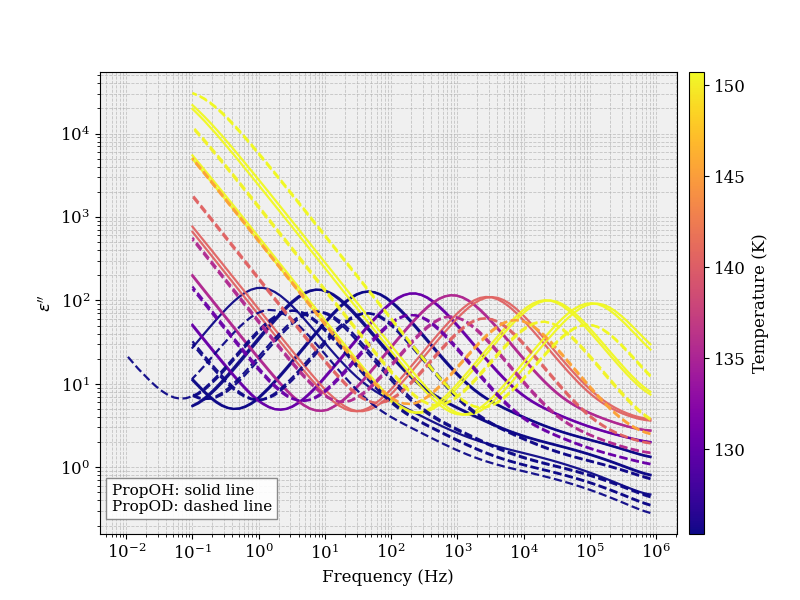

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 12


path = '/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Data/all_dielectric_data/'


# PropOH
H_first, H_last = 18637, 18651    #18637, 18690

# PropOD
D_first, D_last = 18697, 18715     #18695, 18738


def read_diel_file(filepath):
    """Read temperature from header and dielectric spectrum."""
    with open(filepath, 'r') as f:
        T = float(f.readline().split()[1][:-1])  

    df = pd.read_csv(filepath, skiprows=6, delim_whitespace=True, header=None)
    freq = df.iloc[:, 0]     # frequency
    eps2 = df.iloc[:, 6]     # ε''
    return T, freq, eps2

# ------------------------------------------------
# Load datasets
# ------------------------------------------------
def load_dataset(first, last, step=1):
    data = []
    for i in range(first, last + 1, step):
        fname = f"windeta-{i}.diel"
        fpath = os.path.join(path, fname)
        if os.path.exists(fpath):
            T, f, eps2 = read_diel_file(fpath)
            data.append((T, f, eps2))
    return sorted(data, key=lambda x: x[0])

propH_data = load_dataset(H_first, H_last)
propD_data = load_dataset(D_first, D_last)

###just to print###3
print("\n--- PropOH dielectric files being plotted ---")
for i in range(H_first, H_last + 1, 2):
    fname = f"windeta-{i}.diel"
    fpath = os.path.join(path, fname)
    if os.path.exists(fpath):
        with open(fpath, 'r') as f:
            T = float(f.readline().split()[1][:-1])
        print(f"PropOH : File {fname}  →  T = {T:.1f} K")

print("\n--- PropOD dielectric files being plotted ---")
for i in range(D_first, D_last + 1, 2):
    fname = f"windeta-{i}.diel"
    fpath = os.path.join(path, fname)
    if os.path.exists(fpath):
        with open(fpath, 'r') as f:
            T = float(f.readline().split()[1][:-1])
        print(f"PropOD : File {fname}  →  T = {T:.1f} K")



all_temps = [d[0] for d in propH_data + propD_data]

cmap = cm.plasma
norm = mcolors.Normalize(
    vmin=min(all_temps) + 10,
    vmax=max(all_temps) - 10
)

# ------------------------------------------------
# Figure
# ------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('#f0f0f0')

# ------------------------------------------------
# Plot PropOH 
# ------------------------------------------------
for T, freq, eps2 in propH_data:
    ax.loglog(
        freq,
        eps2,
        color=cmap(norm(T)),
        linestyle='-',
        linewidth=1.6,
        alpha=0.95
    )

# ------------------------------------------------
# Plot PropOD (dashed)
# ------------------------------------------------
for T, freq, eps2 in propD_data:
    ax.loglog(
        freq,
        eps2,
        color=cmap(norm(T)),
        linestyle='--',
        linewidth=1.6,
        alpha=0.95
    )

# ----------------
# ------------------------------------------------
ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
ax.set_xlabel(r'Frequency (Hz)')
ax.set_ylabel(r'$\varepsilon^{\prime\prime}$')

# ------------------------------------------------

# ------------------------------------------------
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])


cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02,        #
    fraction=0.05,   # width
    aspect=30        # length
)
cbar.set_label('Temperature (K)')

# ------------------------------------------------

# ------------------------------------------------
ax.text(
    0.02, 0.05,
    "PropOH: solid line\nPropOD: dashed line",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9)
)


plt.show()



Matched PropOH–PropOD temperature pairs:
OH windeta-18649.diel (120.3 K)  ↔  OD windeta-18711.diel (120.5 K)
OH windeta-18647.diel (125.4 K)  ↔  OD windeta-18709.diel (125.5 K)
OH windeta-18645.diel (130.4 K)  ↔  OD windeta-18707.diel (130.5 K)
OH windeta-18643.diel (135.4 K)  ↔  OD windeta-18705.diel (135.5 K)
OH windeta-18641.diel (140.6 K)  ↔  OD windeta-18703.diel (140.5 K)
OH windeta-18639.diel (150.7 K)  ↔  OD windeta-18699.diel (150.5 K)
OH windeta-18637.diel (160.7 K)  ↔  OD windeta-18697.diel (160.4 K)


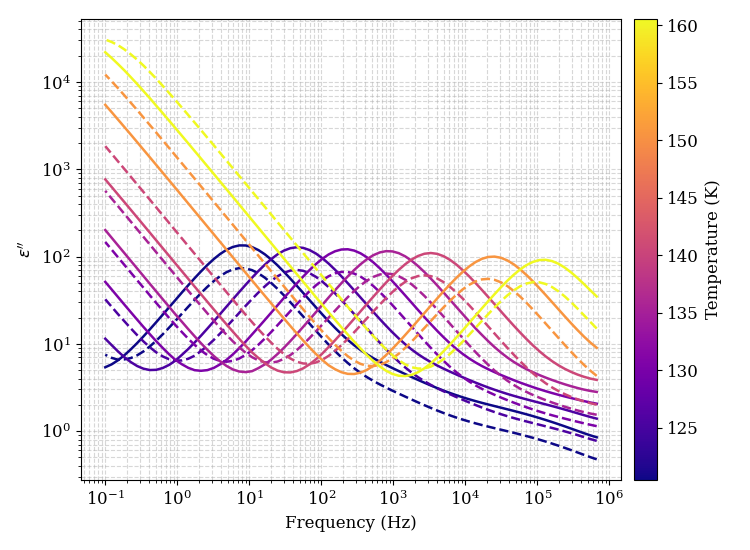

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl


path = '/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Data/all_dielectric_data/'

H_FIRST, H_LAST = 18637, 18651   # PropOH range
D_FIRST, D_LAST = 18697, 18715   # PropOD range
TEMP_TOL = 1.0                  # temperature tolerance in K

# ================= PLOT STYLE =================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12

# =================  =================
def read_temperature(file_path):
    """Read temperature from first line of .diel file"""
    with open(file_path, 'r') as f:
        return float(f.readline().split()[1][:-1])

def load_dataset(first, last, label):
    """Load files and temperatures into a dict"""
    data = {}
    for i in range(first, last + 1, 2):
        fname = f"windeta-{i}.diel"
        fpath = os.path.join(path, fname)
        if os.path.exists(fpath):
            T = read_temperature(fpath)
            df = pd.read_csv(fpath, skiprows=6, delim_whitespace=True)
            data[i] = {"T": T, "df": df, "label": label}
    return data

# ================= LOAD DATA =================
propOH = load_dataset(H_FIRST, H_LAST, "OH")
propOD = load_dataset(D_FIRST, D_LAST, "OD")

# ================= MATCH TEMPERATURES =================
matched_pairs = []

for iH, dH in propOH.items():
    for iD, dD in propOD.items():
        if abs(dH["T"] - dD["T"]) <= TEMP_TOL:
            matched_pairs.append((iH, iD, dH["T"], dD["T"]))

# Sort by average temperature
matched_pairs.sort(key=lambda x: 0.5 * (x[2] + x[3]))

# ================= REPORT =================
print("\nMatched PropOH–PropOD temperature pairs:")
for iH, iD, TH, TD in matched_pairs:
    print(f"OH windeta-{iH}.diel ({TH:.1f} K)  ↔  OD windeta-{iD}.diel ({TD:.1f} K)")

if not matched_pairs:
    raise RuntimeError("No matched temperatures found within tolerance.")

temps_avg = [0.5 * (TH + TD) for _, _, TH, TD in matched_pairs]
norm = mcolors.Normalize(vmin=min(temps_avg), vmax=max(temps_avg))
cmap = cm.plasma

# ================= PLOT =================
fig, ax = plt.subplots(figsize=(7.5, 5.5))

for (iH, iD, TH, TD) in matched_pairs:
    Tavg = 0.5 * (TH + TD)
    color = cmap(norm(Tavg))

    # -------- PropOH (solid) --------
    dfH = propOH[iH]["df"]
    ax.loglog(
        dfH.iloc[:, 0],
        dfH.iloc[:, 6],
        color=color,
        linestyle='-',
        linewidth=1.8
    )

    # -------- PropOD (dashed) --------
    dfD = propOD[iD]["df"]
    ax.loglog(
        dfD.iloc[:, 0],
        dfD.iloc[:, 6],
        color=color,
        linestyle='--',
        linewidth=1.8
    )

# ================= AXES =================
ax.set_xlabel(r'Frequency (Hz)')
ax.set_ylabel(r'$\varepsilon^{\prime\prime}$')
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# ================= COLORBAR =================
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Temperature (K)')

plt.tight_layout()
plt.show()


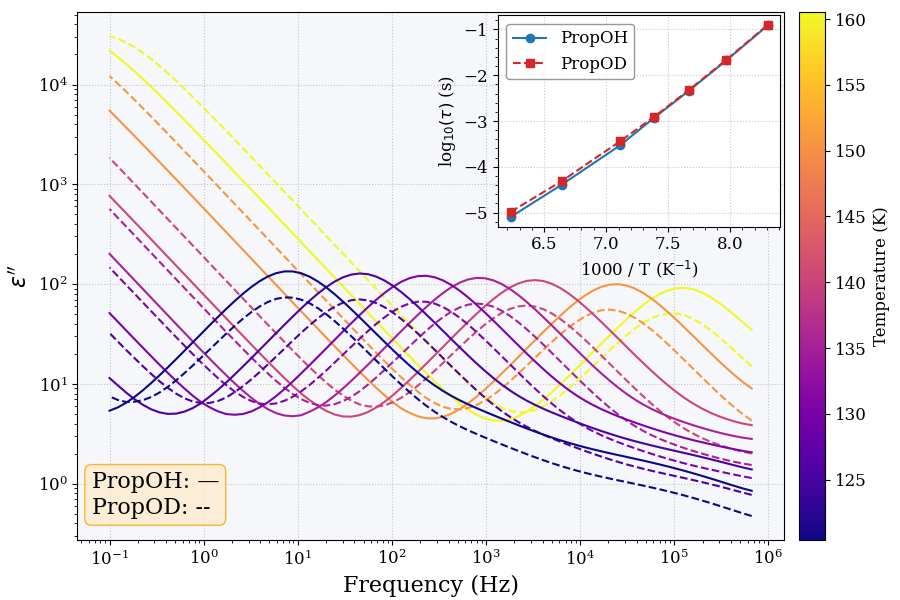

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import rcParams
from scipy.signal import argrelmax
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ------------------    ------------------
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 12

path = '/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Data/all_dielectric_data/'

# PropOH files
OH_first = 18637
OH_last  = 18651

# PropOD files
OD_first = 18697
OD_last  = 18715

T_tolerance = 1.0

def read_dielectric_files(start, end, path, prefix='windeta', label='OH'):
    datasets = []
    for i in range(start, end + 1, 2):
        filename = f"{prefix}-{i}.diel"
        file_path = os.path.join(path, filename)
        if not os.path.isfile(file_path):
            continue
       
        with open(file_path, 'r') as f:
            temp_line = f.readline().split()
            T = round(float(temp_line[1][:-1]), 1)
        
        df = pd.read_csv(file_path, skiprows=6, delim_whitespace=True)
        datasets.append({'file': filename, 'T': T, 'df': df, 'label': label})
    return datasets


propOH = read_dielectric_files(OH_first, OH_last, path, label='PropOH')
propOD = read_dielectric_files(OD_first, OD_last, path, label='PropOD')


matched_pairs = []
for iH, h in enumerate(propOH):
    for iD, d in enumerate(propOD):
        if abs(h['T'] - d['T']) <= T_tolerance:
            matched_pairs.append((iH, iD, h['T'], d['T']))


temperatures = [0.5*(TH+TD) for _,_,TH,TD in matched_pairs]
cmap = cm.plasma
norm = mcolors.Normalize(vmin=min(temperatures), vmax=max(temperatures))


def fmax(df, permittivity_col=6, frequency_col=0):
    permittivity = df.iloc[:, permittivity_col].values
    frequency = df.iloc[:, frequency_col].values

    nbors = 8
    idx0 = argrelmax(permittivity, order=nbors)[0][0]
    N = len(frequency)

    imin = max(0, idx0 - nbors)
    imax = min(N, idx0 + nbors + 1)

   
    p = np.polyfit(frequency[imin:imax], permittivity[imin:imax], deg=6)
    rts = np.roots(np.polyder(p))

   
    fmax_val = rts[np.argmin(np.abs(rts - frequency[idx0]))]

    if np.iscomplex(fmax_val):
        raise RuntimeError(f"Complex root found for fmax in {df}")

    fmax_val = fmax_val.real
    tau = 1 / fmax_val  # re
    return tau

fig, ax = plt.subplots(figsize=(9,6))
fig.subplots_adjust(left=0.086, right=0.93, bottom=0.1, top=0.98)
for iH, iD, TH, TD in matched_pairs:
    Hdata = propOH[iH]
    Ddata = propOD[iD]

    color = cmap(norm(0.5*(TH+TD)))

    # Plot PropOH (solid)
    ax.loglog(Hdata['df'].iloc[:,0], Hdata['df'].iloc[:,6], 
              linestyle='-', marker=None, color=color, linewidth=1.5, label=f'{Hdata["T"]}K OH')

    # Plot PropOD (dashed)
    ax.loglog(Ddata['df'].iloc[:,0], Ddata['df'].iloc[:,6], 
              linestyle='--', marker=None, color=color, linewidth=1.5, label=f'{Ddata["T"]}K OD')

# Axis styling
ax.set_facecolor('#F5F7FA')
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_xlabel('Frequency (Hz)', fontsize=16)
ax.set_ylabel("$ε''$", fontsize=16)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.05)
cbar.set_label('Temperature (K)', fontsize=12)

ax.text(
    0.02, 0.05,
    "PropOH: \u2014\nPropOD: --", # 
    transform=ax.transAxes,
    fontsize=16,
     # Monospace helps alignment
    bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8))


tau_H = []
tau_D = []
T_list = []

for iH, iD, TH, TD in matched_pairs:
    dfH = propOH[iH]['df']
    dfD = propOD[iD]['df']
    tau_H.append(fmax(dfH))
    tau_D.append(fmax(dfD))
    T_list.append(0.5*(TH+TD))

# ------------------ Add Arrhenius inset ------------------
from matplotlib.ticker import AutoMinorLocator
inset_ax = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=0.2)

inset_ax.plot(1000/np.array(T_list), np.log10(tau_H), 'o-', color='tab:blue', label='PropOH')
inset_ax.plot(1000/np.array(T_list), np.log10(tau_D), 's--', color='tab:red', label='PropOD')

inset_ax.set_xlabel(r'1000 / T (K$^{-1}$)', fontsize=12)
inset_ax.set_ylabel(r'log$_{10}(\tau)$ (s)', fontsize=12)
inset_ax.grid(True, linestyle=':', alpha=0.7)
inset_ax.legend( facecolor='white', edgecolor='gray', fontsize=12)
inset_ax.xaxis.set_minor_locator(AutoMinorLocator())
inset_ax.yaxis.set_minor_locator(AutoMinorLocator())
out = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/'
fig.savefig(f"{out}/Dielectric_PropOH_PropOD_temp.pdf")

plt.show()


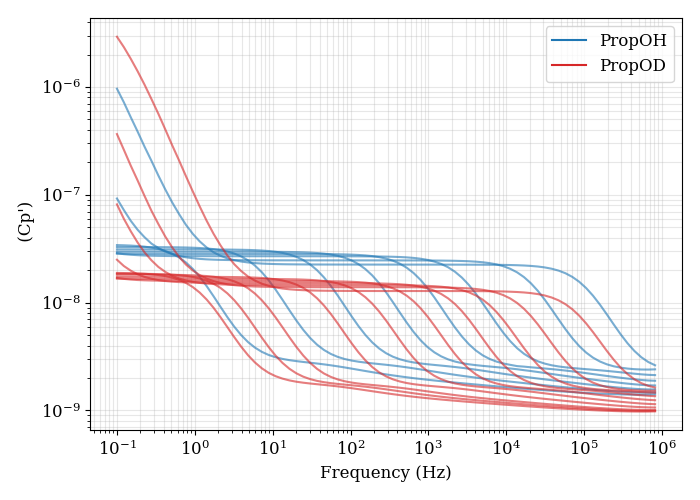

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12


path = '/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Data/all_dielectric_data/'

OH_range = range(18637, 18652, 2)
OD_range = range(18697, 18716, 2)


def read_dielectric_files(file_indices, path):
    datasets = []
    for i in file_indices:
        filename = f"windeta-{i}.diel"
        file_path = os.path.join(path, filename)

        if not os.path.isfile(file_path):
            continue

      
        df = pd.read_csv(
            file_path,
            skiprows=6,
            delim_whitespace=True,
            header=None
        )

        datasets.append(df)

    return datasets


propOH = read_dielectric_files(OH_range, path)
propOD = read_dielectric_files(OD_range, path)

# ------------------ Plotting ------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Plot PropOH
for df in propOH:
    ax.loglog(df.iloc[:, 0], df.iloc[:, 1],
              color='tab:blue', alpha=0.6)

# Plot PropOD
for df in propOD:
    ax.loglog(df.iloc[:, 0], df.iloc[:, 1],
              color='tab:red', alpha=0.6)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(" (Cp')")
ax.grid(True, which='both', alpha=0.3)


ax.plot([], [], color='tab:blue', label='PropOH')
ax.plot([], [], color='tab:red', label='PropOD')
ax.legend()

plt.tight_layout()
plt.show()


In [9]:
plt.clf()
temps= [150, 180, 220, 250, 270, 300, 330, 350, 390]
mean_lifetimes= [477.44729661, 428.47668011, 168.64257888, 153.20531283,  81.05614629,12.78882178 , 18.0612995 , 11.904085 ,    6.40951383]
plt.plot(temps, mean_lifetimes,"-o", color="green", lw=2,label="ambient")

temps1= [120, 150 ,180 ,220, 250, 270, 300 ,330, 350, 390]
mean_lifetimes1= [488.51117714 ,467.66518002, 277.44376341 , 73.37202585 , 75.40870071,43.29931735 , 14.35671738 , 10.66201275,   7.49018138   ,4.20090545]
plt.plot(temps1, mean_lifetimes1,"-o", color="red", lw=2, label="3kbar pressure")

temps2= [120, 150 ,220, 250, 270 ,330]
mean_lifetimes2= [491.56606242 ,482.90335273, 368.54468309, 239.37937746, 139.64945693,28.29015337]

plt.plot(temps2, mean_lifetimes2,"-o", color="blue", lw=2,label="6k")

temps3= [250, 300, 330]
mean_lifetimes3= [339.60075779, 114.33579489,  46.77994935]
plt.plot(temps3, mean_lifetimes3,"-o", color="black", lw=2,label="10k")






# 0k
temps3= [120 150 180 220 250 270 300 330 350 390]
mean_lifetimes3= [339.60075779, 114.33579489,  46.77994935]
plt.plot(temps3, mean_lifetimes3,"-o", color="black", lw=2,label="10k")


plt.legend()
plt.xlabel("temp")
plt.ylabel("avg lifetime")
plt.grid()
# fig.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/temp.pdf")
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1711354999.py, line 25)

In [ ]:
0kbar

Temperatures (K): [120 150 180 220 250 270 300 330 350 390]
Tau (seconds): [5.29660203e-10 5.05910854e-10 3.13281906e-10 7.93940688e-11
 7.84666268e-11 4.44796203e-11 1.45374479e-11 1.02902206e-11
 7.02753200e-12 3.71117491e-12]





6kbar

Temperatures (K): [120 150 220 250 270 330]
Tau (seconds): [5.31113031e-10 5.24040403e-10 4.07335169e-10 2.66100442e-10
 1.52148707e-10 2.90042228e-11]



3kbar

Temperatures (K): [150 180 220 250 270 300 330 350 390]
Tau (seconds): [5.18624090e-10 4.68499009e-10 1.97431948e-10 1.66498815e-10
 8.58207571e-11 1.36336292e-11 1.80271143e-11 1.15908814e-11
 5.93770722e-12]



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------

# 0 kbar
T_0 = np.array([120, 150, 180, 220, 250, 270, 300, 330, 350, 390])
tau_0_s = np.array([
    5.29660203e-10, 5.05910854e-10, 3.13281906e-10, 7.93940688e-11,
    7.84666268e-11, 4.44796203e-11, 1.45374479e-11, 1.02902206e-11,
    7.02753200e-12, 3.71117491e-12
])

# 3 kbar
T_3 = np.array([150, 180, 220, 250, 270, 300, 330, 350, 390])
tau_3_s = np.array([
    5.18624090e-10, 4.68499009e-10, 1.97431948e-10, 1.66498815e-10,
    8.58207571e-11, 1.36336292e-11, 1.80271143e-11,
    1.15908814e-11, 5.93770722e-12
])

# 6 kbar
T_6 = np.array([120, 150, 220, 250, 270, 330])
tau_6_s = np.array([
    5.31113031e-10, 5.24040403e-10, 4.07335169e-10,
    2.66100442e-10, 1.52148707e-10, 2.90042228e-11
])


# -----------------------------

tau_0_ps = tau_0_s * 1e12
tau_3_ps = tau_3_s * 1e12
tau_6_ps = tau_6_s * 1e12



temps3= [250, 300, 330]
mean_lifetimes3= [339.60075779, 114.33579489,  46.77994935]
plt.plot(temps3, mean_lifetimes3,"-o", color="black", lw=2,label="10k")




plt.figure(figsize=(7,5))


plt.plot(T_0, tau_0_ps, "o-", label="0 kbar")
plt.plot(T_3, tau_3_ps, "s-", label="3 kbar")
plt.plot(T_6, tau_6_ps, "^-", label="6 kbar")
plt.plot(temps3, mean_lifetimes3,"-o", color="black", lw=2,label="10k")

plt.xlabel("Temperature (K)")
plt.ylabel(r"$\tau$ (ps)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/Tau_vs_Temperature_ps_all_pressures1.pdf")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


T_0 = np.array([120,150,180,220,250,270,300,330,350,390])
tau_0_ps = np.array([
    5.29660203e-10,5.05910854e-10,3.13281906e-10,7.93940688e-11,
    7.84666268e-11,4.44796203e-11,1.45374479e-11,1.02902206e-11,
    7.02753200e-12,3.71117491e-12]) * 1e12

T_3 = np.array([150,180,220,250,270,300,330,350,390])
tau_3_ps = np.array([
    5.18624090e-10,4.68499009e-10,1.97431948e-10,1.66498815e-10,
    8.58207571e-11,1.36336292e-11,1.80271143e-11,
    1.15908814e-11,5.93770722e-12]) * 1e12

T_6 = np.array([120,150,220,250,270,330])
tau_6_ps = np.array([
    5.31113031e-10,5.24040403e-10,4.07335169e-10,
    2.66100442e-10,1.52148707e-10,2.90042228e-11]) * 1e12

T_10 = np.array([250,300,330])
tau_10_ps = np.array([339.60075779,114.33579489,46.77994935])


# ======================================================
# 2. PLOTTING
# ======================================================

fig, ax = plt.subplots(figsize=(9,6))
ax.set_facecolor('#F5F7FA')
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.1, top=0.98, hspace=0.03)
# ax.set_facecolor("white")

colors = {0:"#d62728", 3:"#1f77b4", 6:"#2ca02c", 10:"black"}

# ---- Plot data ----
ax.plot(T_0, tau_0_ps, 's-', color=colors[0],
        markersize=6, lw=2, label="0 kbar")

ax.plot(T_3, tau_3_ps, 's-', color=colors[3],
        markersize=6, lw=2, label="3 kbar")

ax.plot(T_6, tau_6_ps, 's-', color=colors[6],
        markersize=6, lw=2, label="6 kbar")

ax.plot(T_10, tau_10_ps, 'o-', color=colors[10],
        markersize=6, lw=2, label="10 kbar")


# ======================================================
# 3. FORMATTING
# ======================================================

ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel(r"$\tau$ (ps)", fontsize=12)

ax.grid(True, linestyle=':', alpha=0.7)

ax.legend(loc="upper right",
          fontsize=12,
          frameon=True,
          ncol=1, framealpha=1,facecolor='white')

# plt.tight_layout()
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/lifetime.pdf')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Lorentzian IFWS model ----------
def IFWS_intensity(T, Ea, Gamma0, A0=2e-4, E0=3.0):
    """
    T      : Temperature (K)
    Ea     : Activation energy (K)
    Gamma0 : High-temperature linewidth prefactor (µeV)
    A0     : Intensity scale
    E0     : Fixed offset energy (µeV) — ~3 µeV for IN16B
    """
    Gamma = Gamma0 * np.exp(-Ea / T)
    return A0 / np.pi / Gamma / (1 + (E0 / Gamma) ** 2)



T = np.linspace(5, 350, 600)  # typical experimental range


# --------
E0 = 3.0        # µeV (fixed window offset for IN16B)
A0 = 2e-4       # typical IFWS intensity scale

Ea_values = [600, 900, 1200, 1600]      # activation energies (K)
Gamma0_values = [0.15, 0.25, 0.40]      # µeV


# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)


for Ea in Ea_values:
    I = IFWS_intensity(T, Ea, Gamma0=0.25, A0=A0, E0=E0)
    axes[0].plot(T, I, label=f"$E_a$ = {Ea} K")

axes[0].set_title("Effect of Activation Energy")
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("IFWS Intensity (arb. units)")
axes[0].legend()
axes[0].grid(True)


# --- Right panel: effect of Gamma0 ---
for G0 in Gamma0_values:
    I = IFWS_intensity(T, Ea=1200, Gamma0=G0, A0=A0, E0=E0)
    axes[1].plot(T, I, label=f"$\\Gamma_0$ = {G0} µeV")

axes[1].set_title("Effect of High-T Linewidth ($\\Gamma_0$)")
axes[1].set_xlabel("Temperature (K)")
axes[1].legend()
axes[1].grid(True)


plt.suptitle("Evolution of Lorentzian IFWS Model with Physical Parameters",
             fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
# plot lorentzian_ifws curves for different amplitude and different actiavtion energy  
from IPython.display import display, Latex

latex_representation = r"""
\begin{align*}
\text{Arrhenius:} \\
\boldsymbol{\Gamma}(T,E_a) &= \Gamma_0 \exp\left(-\frac{E_a}{T}\right) \\
\boldsymbol{\Gamma} (T,E_a)&= \max(\Gamma, 1 \times 10^{-12}) \\

\text{Simple Lorentzian:} \\
\mathbf{L}(E,\Gamma) &= \frac{{\Gamma}}{\pi \left( (E - E_0)^2 + {\Gamma}^2 \right)}     \\
\text{where:} \\
{\Gamma} &\text{ is the half-width at half-maximum (HWHM),} \\
E &\text{ is the energy,} \\
E_0 &\text{ is the peak position.}  \\

\mathbf{L}(T, E_a, \Gamma_0, A_0, E_{\text{offset}}) &= \frac{A_0}{\pi {\Gamma}(T,E_a) \left(1 + \left(\frac{E_{\text{offset}}}{{\Gamma}(T,E_a)}\right)^2\right)} \\

\text{LorentzianIFWS:} \\

         \mathbf{L}(T, E_a, \Gamma_0, A_0, E_{\text{offset}}) &= \frac{A_0}{\pi {\Gamma_0 \exp\left(-\frac{E_a}{k_b T}\right) \\} \left(1 + \left(\frac{E_{\text{offset}}}{\boldsymbol{\Gamma_0 \exp\left(-\frac{E_a}{k_b T}\right) \\}}\right)^2\right)}  \\

\text{KWWIFWS:} \\

         \boldsymbol{\Gamma}(T,E_a) &= \Gamma_0 \exp\left(-\frac{\text{$E_a$}}{T - T_0}\right) \\
         \mathbf{K}(\beta,E_{\text{offset}},T, E_a, A_0) &=\frac{A_0}{\pi} \frac{\exp\left(- \left(\frac{\text{FixedOffsetEnergy}}{{\Gamma}(T,E_a)}\right)^\beta\right)}{{\Gamma}(T,E_a)}

\end{align*}
"""

display(Latex(r"\displaystyle " + latex_representation))


#lorentzian

E = np.linspace(-2,2,1000)
amplitudes = np.linspace(1,2,5)
HWHMs = [0.1]
E0 = 0 

def lorentzian(E, A0, HWHM, E0):
    return (A0 * HWHM) / (np.pi * ((E - E0)**2 + HWHM**2))








E = np.linspace(-2,2,1000)
amplitudes = [1]
HWHMs = np.linspace(0.1,1,10)
E0 = 0 

plt.figure(figsize=(10, 6))
for A0 in amplitudes:
    for HWHM in HWHMs:
        y = lorentzian(E, A0, HWHM, E0)
        plt.plot(E, y, label=f'A0={A0:.4e}, HWHM={HWHM:.4e}')   #label=f'E0 = {E0:.2e}


plt.xlabel('E')
plt.ylabel('Lorentzian(E)')
plt.title('Lorentzian Simple Function for Different Gammas')
plt.legend()
plt.grid(True)




FixedOffsetEnergy = 3e-3  # in meV
Ea = 1656.53  # in Kelvin
Ea_values=[100,500,1000,1500,2000,3000]#np.linspace(1000, 2000, 5)
ga_values=np.linspace(10, 100, 5)
Gamma0 = 13.49  # in meV
Kb = 1#8.617333262145e-5  # Boltzmann constant in eV/K
# print(np.column_stack((E0[:, 0], T[:1], f_gamma[:, 2])))
T = np.linspace(0, 500, 1000)

A0_values = np.linspace(1.78e-06, 9.8e-06, 5)

def lorentzian_ifws(T, Ea, Gamma0, A0, FixedOffsetEnergy):
    Gamma = Gamma0 * np.exp(-Ea / (Kb * T))
    # to avoid division by zero or very small values
    Gamma[Gamma < 1e-12] = 1e-12
    return A0 / (np.pi * Gamma * (1 + (FixedOffsetEnergy / Gamma)**2))
plt.figure(figsize=(10, 6))



plt.figure(figsize=(10, 6))
for E0 in Ea_values:
    f_T_ea = lorentzian_ifws(T, E0, Gamma0, 1.78e-06, FixedOffsetEnergy)
    plt.plot(T, f_T_ea,':', label=f'Ea = {E0:.2e}',marker='o',markersize=3)



plt.xlabel('Temperature (K)')
plt.ylabel('f(T)')
plt.title('Lorentzian IFWS Model varying Activation energy')
plt.legend()
plt.grid(True)
plt.show()



FixedOffsetEnergy = 3e-3  # in meV
Ea = 1656.53  # in Kelvin
Ea_values=np.linspace(1000, 2000, 5)
ga_values=np.linspace(10, 100, 5)
Gamma0 = 13.49  # in meV
Kb = 1#8.617333262145e-5  # Boltzmann constant in eV/K

T = np.linspace(30, 400, 1000)

A0_values = np.linspace(1.78e-06, 9.8e-06, 5)

def lorentzian_ifws(T, Ea, Gamma0, A0, FixedOffsetEnergy):
    Gamma = Gamma0 * np.exp(-Ea / (Kb * T))
    # to avoid division by zero or very small values
    Gamma[Gamma < 1e-12] = 1e-12
    return A0 / (np.pi * Gamma * (1 + (FixedOffsetEnergy / Gamma)**2))


plt.figure(figsize=(10, 6))


for ga in ga_values:
    f_T = lorentzian_ifws(T, 1656.53, ga, 1.78e-06, FixedOffsetEnergy)
    plt.plot(T, f_T, '-',label=f'ga = {ga:.2e}',markersize=2)


plt.xlabel('Temperature (K)')
plt.ylabel('f(T)')
plt.title('Lorentzian IFWS Model varying Gamma_0')
plt.legend()
plt.grid(True)
plt.show()



FixedOffsetEnergy = 6e-3  # in meV

FixedOffsetEnergy_values=np.linspace(3e-3, 6e-3, 3)
Ea = 1656.53  # in Kelvin
Ea_values=np.linspace(1000, 2000, 5)
ga_values=np.linspace(10, 100, 5)
Gamma0 = 13.49  # in meV
Kb = 1#8.617333262145e-5  # Boltzmann constant in eV/K

T = np.linspace(30, 400, 1000)

A0_values = np.linspace(1.78e-06, 9.8e-06, 5)

def lorentzian_ifws(T, Ea, Gamma0, A0, FixedOffsetEnergy):
    Gamma = Gamma0 * np.exp(-Ea / (Kb * T))
    
    Gamma[Gamma < 1e-12] = 1e-12
    return A0 / (np.pi * Gamma * (1 + (FixedOffsetEnergy / Gamma)**2))


plt.figure(figsize=(10, 6))
for FixedOffsetEnergy in FixedOffsetEnergy_values:
    f_T = lorentzian_ifws(T, 1656.53, 13.49, 1.78e-06, FixedOffsetEnergy)
    plt.plot(T, f_T, 'o-',label=f'FixedOffsetEnergy = {FixedOffsetEnergy:.2e}',markersize=2)




plt.xlabel('Temperature (K)')
plt.ylabel('f(T)')
plt.title('Lorentzian IFWS Model varying FixedOffsetEnergy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ================================

# ================================
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif']  = ['DejaVu Serif']
plt.rcParams["font.size"] = 9
plt.rcParams["axes.facecolor"] = "#F5F7FA"
plt.rcParams["grid.alpha"] = 0.4

# ================================
# Functions
# ================================
def lorentzian(E, A0, HWHM, E0):
    return (A0 * HWHM) / (np.pi * ((E - E0)**2 + HWHM**2))

def lorentzian_ifws(T, Ea, Gamma0, A0, FixedOffsetEnergy, Kb=1):
    Gamma = Gamma0 * np.exp(-Ea / (Kb * T))
    Gamma[Gamma < 1e-12] = 1e-12
    return A0 / (np.pi * Gamma * (1 + (FixedOffsetEnergy / Gamma)**2))

# ================================
# Parameters
# ================================
T = np.linspace(30, 500, 1000)
E = np.linspace(-2, 2, 1000)

A0 = 1.78e-6
Gamma0_base = 13.49
Ea_base = 1656.53
FixedOffsetEnergy_base = 3e-3

Ea_values = [500, 1000, 1500, 2500]
FixedOffsetEnergy_values = np.linspace(2e-3, 8e-3, 4)
Gamma0_values = np.linspace(10, 100, 5)

HWHMs = np.linspace(0.1, 1, 6)
E0 = 0

# ================================
# ================================
textbox_pos = {
    "a": (0.7, 0.50),
    "b": (0.65, 0.50),
    "c": (0.7, 0.45),
    "d": (0.05, 0.90)
}

# ================================

# ================================
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.085, top=0.97,hspace=0.2)
(ax1, ax2), (ax3, ax4) = axes

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))

# ==========================
# =========================================================
for Ea in Ea_values:
    f = lorentzian_ifws(T, Ea, Gamma0_base, A0, FixedOffsetEnergy_base)
    ax1.plot(T, f, label=f"Ea={Ea} K")

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("IFWS Intensity")
ax1.grid(True, linestyle=':', alpha=1)
ax1.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=10, loc='upper right', ncol=1)
ax1.yaxis.set_major_formatter(formatter)

ax1.text(*textbox_pos["a"], "(a) IFWS ($E_a$)",
         transform=ax1.transAxes,fontsize=12,
         bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))

# =========================================================
# (0,1) IFWS varying FixedOffsetEnergy
# =========================================================
for fe in FixedOffsetEnergy_values:
    f = lorentzian_ifws(T, Ea_base, Gamma0_base, A0, fe)
    ax2.plot(T, f, label=f"Eoff={fe:.1e}meV")

ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel("IFWS Intensity")
ax2.grid(True, linestyle=':', alpha=1)
ax2.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=10, loc='upper right', ncol=1)
ax2.yaxis.set_major_formatter(formatter)

ax2.text(*textbox_pos["b"], "(b) IFWS ($E_{offset})$",
         transform=ax2.transAxes,fontsize=12,
         bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))


# frameon=True, facecolor="white", edgecolor='gray', fontsize=12, loc='upper right', ncol=1
# =========================================================
# (1,0) IFWS varying Gamma0
# =========================================================
for g0 in Gamma0_values:
    f = lorentzian_ifws(T, Ea_base, g0, A0, FixedOffsetEnergy_base)
    ax3.plot(T, f, label=f"Gamma0={g0:.1f}meV")

ax3.set_xlabel("Temperature (K)")
ax3.set_ylabel("IFWS Intensity")
ax3.grid(True, linestyle=':', alpha=1)
ax3.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=10, loc='upper right', ncol=1)
ax3.yaxis.set_major_formatter(formatter)

ax3.text(*textbox_pos["c"], "(c) IFWS ($\\Gamma_0$)",
         transform=ax3.transAxes,fontsize=12,
         bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))

# =========================================================
# (1,1) Simple Lorentzian
# =========================================================
for h in HWHMs:
    y = lorentzian(E, 1, h, E0)
    ax4.plot(E, y, label=f"HWHM={h:.2f}meV")

ax4.set_xlabel("Energy (meV)")
ax4.set_ylabel("Lorentzian(E)")
ax4.grid(True, linestyle=':', alpha=1)

ax4.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=10, loc='upper right', ncol=1)
ax4.yaxis.set_major_formatter(formatter)

ax4.text(*textbox_pos["d"], "(d) Lorentzian QENS",
         transform=ax4.transAxes,fontsize=12,
         bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))

# ================================
# Layout
# ================================
# plt.tight_layout()
plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/functions.pdf")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib import rcParams

# =========================================================
# Global plot style 
# =========================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']

plt.rcParams["font.size"] = 9
plt.rcParams["axes.facecolor"] = "#F5F7FA"
plt.rcParams["grid.alpha"] = 0.4

# =========================================================
# Physical constants
# =========================================================
kB = 8.617333262e-2   # Boltzmann constant in meV/K

# =========================================================
# Functions
# =========================================================
def lorentzian(E, A0, HWHM, E0):
    """
    Lorentzian line shape
    E      : energy transfer (µeV)
    HWHM   : half width at half maximum (µeV)
    """
    return (A0 * HWHM) / (np.pi * ((E - E0)**2 + HWHM**2))


def lorentzian_ifws(T, Ea, Gamma0, A0, FixedOffsetEnergy):
    """
    Simplified IFWS intensity model

    Ea                : activation energy (meV)
    Gamma0            : prefactor linewidth (µeV)
    FixedOffsetEnergy : offset energy (µeV)
    """

    # Arrhenius linewidth
    Gamma = Gamma0 * np.exp(-Ea / (kB * T))

    # Avoid divide-by-zero
    Gamma[Gamma < 1e-6] = 1e-6

    return A0 / (np.pi * Gamma * (1 + (FixedOffsetEnergy / Gamma)**2))


# =========================================================
#  IN16B parameters
# =========================================================

# Temperature range
T = np.linspace(2, 500, 1000)

# IN16B standard dynamic range ~ ±30 µeV
E = np.linspace(-30, 30, 2000)

# Intensity scaling
A0 = 1.0


Ea_base = 15.0  # meV

Ea_values = [5, 10, 15, 25]  # meV


FixedOffsetEnergy_base = 2.6  # µeV

FixedOffsetEnergy_values = [1.0, 1.3, 2.6, 5.0]  # µeV


Gamma0_base = 10.0  # µeV

Gamma0_values = [2, 5, 10, 20, 30]  # µeV

HWHMs = [0.3, 0.5, 1, 2, 5, 10]

E0 = 0

# =========================================================
# Textbox positions
# =========================================================
textbox_pos = {
    "a": (0.68, 0.50),
    "b": (0.60, 0.50),
    "c": (0.68, 0.45),
    "d": (0.05, 0.90)
}

# =========================================================
# Create figure
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.085,
    top=0.97,
    hspace=0.20
)

(ax1, ax2), (ax3, ax4) = axes

# =========================================================
# Scientific notation formatter
# =========================================================
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))

# =========================================================
# (a) IFWS varying Ea
# =========================================================
for Ea in Ea_values:

    f = lorentzian_ifws(
        T,
        Ea,
        Gamma0_base,
        A0,
        FixedOffsetEnergy_base
    )

    ax1.plot(T, f, label=f"$E_a$ = {Ea} meV")

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("IFWS Intensity (a.u.)")

ax1.grid(True, linestyle=':', alpha=1)

ax1.legend(fontsize=9, frameon=True)

ax1.yaxis.set_major_formatter(formatter)

ax1.text(
    *textbox_pos["a"],
    "(a) IFWS ($E_a$)",
    transform=ax1.transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
)


for fe in FixedOffsetEnergy_values:

    f = lorentzian_ifws(
        T,
        Ea_base,
        Gamma0_base,
        A0,
        fe
    )

    ax2.plot(T, f, label=f"$E_{{off}}$ = {fe:.1f} µeV")

ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel("IFWS Intensity (a.u.)")

ax2.grid(True, linestyle=':', alpha=1)

ax2.legend(fontsize=9, frameon=True)

ax2.yaxis.set_major_formatter(formatter)

ax2.text(
    *textbox_pos["b"],
    "(b) IFWS ($E_{offset}$)",
    transform=ax2.transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
)


for g0 in Gamma0_values:

    f = lorentzian_ifws(
        T,
        Ea_base,
        g0,
        A0,
        FixedOffsetEnergy_base
    )

    ax3.plot(T, f, label=f"$\\Gamma_0$ = {g0} µeV")

ax3.set_xlabel("Temperature (K)")
ax3.set_ylabel("IFWS Intensity (a.u.)")

ax3.grid(True, linestyle=':', alpha=1)

ax3.legend(fontsize=9, frameon=True)

ax3.yaxis.set_major_formatter(formatter)

ax3.text(
    *textbox_pos["c"],
    "(c) IFWS ($\\Gamma_0$)",
    transform=ax3.transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
)

# =========================================================
# (d) Lorentzian QENS
# =========================================================
for h in HWHMs:

    y = lorentzian(E, 1, h, E0)

    ax4.plot(E, y, label=f"HWHM = {h:.1f} µeV")

ax4.set_xlabel("Energy Transfer (µeV)")
ax4.set_ylabel("Lorentzian(E)")

ax4.grid(True, linestyle=':', alpha=1)

ax4.legend(fontsize=9, frameon=True)

ax4.yaxis.set_major_formatter(formatter)

ax4.text(
    *textbox_pos["d"],
    "(d) Lorentzian QENS",
    transform=ax4.transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
)

# =========================================================
# Layout and save
# =========================================================
plt.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/functions22.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib import rcParams

# ==========================================================
# GLOBAL PLOT SETTINGS
# ==========================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "lines.linewidth": 2.0,
})

def apply_plot_style(ax):
    """Applies your custom facecolor, grid, and tick style."""
    ax.set_facecolor('#F5F7FA')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(which="both", direction="in", top=True, right=True)

# ================================
# Functions
# ================================
def lorentzian(E, A0, HWHM, E0):
    return (A0 * HWHM) / (np.pi * ((E - E0)**2 + HWHM**2))

def lorentzian_ifws(T, Ea, Gamma0, A0, FixedOffsetEnergy, Kb=1):
    Gamma = Gamma0 * np.exp(-Ea / (Kb * T))
    Gamma[Gamma < 1e-12] = 1e-12
    return A0 / (np.pi * Gamma * (1 + (FixedOffsetEnergy / Gamma)**2))

# ================================
# Parameters
# ================================
T = np.linspace(30, 500, 1000)
E = np.linspace(-2, 2, 1000)

A0 = 1.78e-6
Gamma0_base = 13.49
Ea_base = 1656.53
FixedOffsetEnergy_base = 3e-3

Ea_values = [500, 1000, 1500, 2500]
FixedOffsetEnergy_values = np.linspace(2e-3, 8e-3, 4)
Gamma0_values = np.linspace(10, 100, 5)
HWHMs = np.linspace(0.1, 1, 6)
E0 = 0

# ================================
# Create figure
# ================================
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(left=0.06, right=0.98, bottom=0.075, top=0.97, hspace=0.18, wspace=0.18)
(ax1, ax2), (ax3, ax4) = axes

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))

# =========================================================
# Plotting
# =========================================================
# (0,0) IFWS varying Ea
for Ea in Ea_values:
    ax1.plot(T, lorentzian_ifws(T, Ea, Gamma0_base, A0, FixedOffsetEnergy_base), label=f"Ea={Ea} K")
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("IFWS Intensity")
ax1.yaxis.set_major_formatter(formatter)
apply_plot_style(ax1)
ax1.legend(frameon=True,facecolor='white', edgecolor='gray')
ax1.text(0.7, 0.5, "(a) IFWS ($E_a$)", transform=ax1.transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# (0,1) IFWS varying FixedOffsetEnergy
for fe in FixedOffsetEnergy_values:
    ax2.plot(T, lorentzian_ifws(T, Ea_base, Gamma0_base, A0, fe), label=f"Eoff={fe:.2e}")
ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel("IFWS Intensity")
ax2.yaxis.set_major_formatter(formatter)
apply_plot_style(ax2)
ax2.legend(frameon=True,facecolor='white', edgecolor='gray')
ax2.text(0.65, 0.5, "(b) IFWS ($E_{offset}$)", transform=ax2.transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# (1,0) IFWS varying Gamma0
for g0 in Gamma0_values:
    ax3.plot(T, lorentzian_ifws(T, Ea_base, g0, A0, FixedOffsetEnergy_base), label=f"Gamma0={g0:.1f}")
ax3.set_xlabel("Temperature (K)")
ax3.set_ylabel("IFWS Intensity")
ax3.yaxis.set_major_formatter(formatter)
apply_plot_style(ax3)
ax3.legend(frameon=True,facecolor='white', edgecolor='gray')
ax3.text(0.65, 0.5, "(c) IFWS ($\Gamma_0$)", transform=ax3.transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# (1,1) Simple Lorentzian
for h in HWHMs:
    ax4.plot(E, lorentzian(E, 1, h, E0), label=f"HWHM={h:.2f}")
ax4.set_xlabel("Energy (meV)")
ax4.set_ylabel("Lorentzian(E)")
ax4.yaxis.set_major_formatter(formatter)
apply_plot_style(ax4)
ax4.legend(frameon=True,facecolor='white', edgecolor='gray')
ax4.text(0.05, 0.9, "(d) Lorentzian QENS", transform=ax4.transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))


plt.show()

In [ ]:
#thesis glycerol

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import rcParams
# ======================================================

# ======================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']

def load_diel(path, i):
    file = f"windeta-{i}.diel"
    # Fixed 'jointriangle' to 'path.join'
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as f:
        content = f.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        T = round(float(t_start_match.group(1)), 1) if t_start_match else 0
        p = round(float(p_start_match.group(1)), 1) if p_start_match else 0

    
    df = pd.read_csv(file_path, skiprows=5, sep='\s+', header=0, 
                     names=["Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    df = df.iloc[5:-5]
    df['T'] = T
    df['p'] = p
    return df


path = '/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Data/all_dielectric_data/'
# Replace range with actual file indices
G9P_3Kbar = [load_diel(path, i) for i in range(18528, 18550, 2)]


plt.rcParams['axes.facecolor'] = '#F5F7FA'  # 
fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(
        left=0.09,
        right=0.98,
        bottom=0.10,
        top=0.98,
        hspace=0.03
    )


cmap_name = 'rainbow'
cmap = plt.get_cmap(cmap_name)


all_temps = [df['T'].iloc[0] for df in G9P_3Kbar]
norm = mpl.colors.Normalize(vmin=min(all_temps), vmax=max(all_temps))

for df in G9P_3Kbar:
    T = df['T'].iloc[0]
    color = cmap(norm(T))
    ax.plot(df.index, df["Eps''"], color=color, linewidth=2.5, linestyle='-')

# Styling
ax.set_yscale('log')
ax.set_xscale('log')
# ax.grid(True, linestyle='-', linewidth=0.6, color='white') # White grid on gray looks clean
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel(r"$\epsilon''$", fontweight='bold', fontsize=12)
ax.set_ylim(0.06,200)
ax.grid(True, linestyle=':', alpha=0.5)


cbar_x = 0.45      #
cbar_y = 0.86      # Vertical position (above plot)
cbar_width = 0.43   # Width of bar
cbar_height = 0.03 # Thickness of bar

cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')


tick_locs = np.linspace(min(all_temps), max(all_temps), 5)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t:.1f} K" for t in tick_locs])
cbar.ax.tick_params(labelsize=9)
cbar.set_label('Temperature (K)', fontsize=12, labelpad=-50) # Adjusted label fontweight='bold',
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/Glyd.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/Glyd.png',dpi=300)
# ax.grid(True, linestyle=':', alpha=0.5)
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Conferences and seminars/HIRES2026/glyd.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Conferences and seminars/HIRES2026/glyd.png',dpi=300)
plt.show()

# prop_0Kbar = [load_diel(path, i) for i in range(19994, 20073, 3)]


In [ ]:
#thesis propanol
# prop_0Kbar = [load_diel(path, i) for i in range(19994, 20073, 3)]
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def load_diel(path, i):
    file = f"windeta-{i}.diel"
    # Fixed 'jointriangle' to 'path.join'
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as f:
        content = f.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        T = round(float(t_start_match.group(1)), 1) if t_start_match else 0
        p = round(float(p_start_match.group(1)), 1) if p_start_match else 0

    # Using sep='\s+' for modern pandas
    df = pd.read_csv(file_path, skiprows=5, sep='\s+', header=0, 
                     names=["Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    df = df.iloc[5:-5]
    df['T'] = T
    df['p'] = p
    return df

# --- Data Loading ---
# path = '/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Data/all_dielectric_data/'
path = '/home/tiwari/in16bdielectricwf/data/'
# Replace range with actual file indices
G9P_3Kbar = [load_diel(path, i) for i in range(20010, 20070, 6)]#19994

# --- Plotting Setup ---
plt.rcParams['axes.facecolor'] = '#F5F7FA'  #
fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(
        left=0.09,
        right=0.98,
        bottom=0.10,
        top=0.98,
        hspace=0.03
    )

# Define Colormap
cmap_name = 'rainbow'
cmap = plt.get_cmap(cmap_name)

# Extract T values for normalization
all_temps = [df['T'].iloc[0] for df in G9P_3Kbar]
norm = mpl.colors.Normalize(vmin=min(all_temps), vmax=max(all_temps))

for df in G9P_3Kbar:
    T = df['T'].iloc[0]
    color = cmap(norm(T))
    # Using index as x-axis (assuming it represents frequency)
    ax.plot(df.index, df["Eps''"], color=color, linewidth=2.5, linestyle='-')

# Styling
ax.set_yscale('log')
ax.set_xscale('log')
# ax.grid(True, linestyle='-', linewidth=0.6, color='white') # White grid on gray looks clean
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel(r"$\epsilon''$", fontweight='bold', fontsize=12)
ax.set_ylim(0.06,200)
# ax.set_title('Glycerol at Ambient Pressure', fontsize=16, pad=60) # Increased pad for cbar space

# --- Custom Colorbar on Top ---
# Parameters to change size and position
cbar_x = 0.53      # Horizontal position
cbar_y = 0.86      # Vertical position (above plot)
cbar_width = 0.4   # Width of bar
cbar_height = 0.03 # Thickness of bar

cax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')

# Set exactly 5 ticks based on min/max temp
tick_locs = np.linspace(min(all_temps), max(all_temps), 5)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t:.1f} K" for t in tick_locs])
cbar.ax.tick_params(labelsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
cbar.set_label('Temperature (K)', fontsize=12, labelpad=-50) # Adjusted label fontweight='bold',
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/propd.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Conferences and seminars/HIRES2026/propd.png',dpi=300)
plt.show()




In [ ]:
import math

# Density of 1-propanol (g/mL)
density = 0.803

# Cell dimensions (mm)
outer_diameter = 16
height = 40

inner_diameters = [15, 14, 13, 11]

# Convert to cm
R_outer = (outer_diameter / 2) / 10
h = height / 10

for d in inner_diameters:
    
    R_inner = (d / 2) / 10
    
    volume_ml = math.pi * h * (R_outer**2 - R_inner**2)
    mass_g = volume_ml * density
    
    print(f"Inner rod diameter: {d} mm")
    print(f"Sample volume: {volume_ml:.3f} mL")
    print(f"Sample mass: {mass_g:.3f} g\n")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.clf()
# =========================
# Load data
# =========================
prop_0Kbar = [load_diel(path, i) for i in range(19994, 20073)]
prop_3Kbar = [load_diel(path, i) for i in range(20367, 20403)]

# =========================
#
# =========================
sel_0Kbar = prop_0Kbar[::max(1, len(prop_0Kbar)//8)][:8]
sel_3Kbar = prop_3Kbar[::max(1, len(prop_3Kbar)//8)][:8]

# =========================
# Temperature tolerance grouping
# =========================
TOL = 2.0  # K

def group_temperatures(dfs, tol=2.0):
    temps = sorted([df['T'].iloc[0] for df in dfs])
    groups = []

    for T in temps:
        if not groups or abs(T - groups[-1]) > tol:
            groups.append(T)

    return groups

# All temperatures
all_dfs = sel_0Kbar + sel_3Kbar
rep_temps = group_temperatures(all_dfs, TOL)

# Map each curve to representative temperature
def representative_T(T, reps):
    return min(reps, key=lambda r: abs(T - r))

# =========================
# Colormap (temperature only)
# =========================
cmap = plt.get_cmap('tab10')
color_map = {T: cmap(i % 10) for i, T in enumerate(rep_temps)}

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(9,6))
fig.subplots_adjust(left=0.10, right=0.98,bottom=0.10, top=0.97,hspace=0.03)

# =========================
# Plot 0 kbar (solid, thick)
# =========================
for df in sel_0Kbar:
    T = df['T'].iloc[0]
    T_rep = representative_T(T, rep_temps)
    color = color_map[T_rep]

    x = df.index.values
    y = df["Eps''"].values

    ax.plot(
        x, y,
        linestyle='-',
        linewidth=2.8,
        color=color
    )

    i_max = np.argmax(y)
    ax.text(
        x[i_max]*0.85,
        y[i_max],
        f"{T_rep:.0f} ",
        color=color,
        fontsize=12,
        ha='center'
    )

# =========================
# Plot 3 kbar (same color, dashed + markers)
# =========================
for df in sel_3Kbar:
    T = df['T'].iloc[0]
    T_rep = representative_T(T, rep_temps)
    color = color_map[T_rep]

    x = df.index.values
    y = df["Eps''"].values

    ax.plot(
        x, y,
        linestyle='--',
        linewidth=2.0,
        marker='o',
        markersize=4,
        markevery=12,
        color=color
    )

    i_max = np.argmax(y)
    ax.text(
        x[i_max],
        y[i_max],
        f"{T_rep:.0f}",
        color=color,
        fontsize=12,
        ha='center'
    )

# =========================
# Axes & styling
# =========================
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('f (Hz)', fontsize=16, fontweight='bold')
ax.set_ylabel(r'$\boldsymbol{\varepsilon}^{\prime\prime}$', fontsize=14)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=1)

# plt.tight_layout()
# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/Dielectric_D.pdf", dpi=300)
plt.show()

# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.clf()
# =========================
# Load data
# =========================
prop_0Kbar = [load_diel(path, i) for i in range(19994, 20073)]
prop_3Kbar = [load_diel(path, i) for i in range(20367, 20403)]

# =========================
# Select ~5 curves evenly
# =========================
sel_0Kbar = prop_0Kbar[::max(1, len(prop_0Kbar)//6)][:6]
sel_3Kbar = prop_3Kbar[::max(1, len(prop_3Kbar)//6)][:6]

# =========================
# Temperature tolerance grouping
# =========================
TOL = 2.0  # K

def group_temperatures(dfs, tol=2.0):
    temps = sorted([df['T'].iloc[0] for df in dfs])
    groups = []

    for T in temps:
        if not groups or abs(T - groups[-1]) > tol:
            groups.append(T)

    return groups

# All temperatures
all_dfs = sel_0Kbar + sel_3Kbar
rep_temps = group_temperatures(all_dfs, TOL)

# Map each curve to representative temperature
def representative_T(T, reps):
    return min(reps, key=lambda r: abs(T - r))

# =========================
# Colormap (temperature only)
# =========================
cmap = plt.get_cmap('tab10')
color_map = {T: cmap(i % 10) for i, T in enumerate(rep_temps)}

# =========================
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.1, top=0.98)

# --- Set Axis Limits (Adjust these to fit your data range) ---
# ax.set_xlim(1, 1e7)        
# ax.set_ylim(0.01, 100)     

# =========================================================
# Plotting and Labeling Function
# =========================================================
# =========================
# Plotting and Labeling
# =========================
import random # Add this import at the top

def plot_and_label(dfs, linestyle, marker=None):
    for df in dfs:
        T = df['T'].iloc[0]
        T_rep = representative_T(T, rep_temps)
        color = color_map[T_rep]

        x_vals = df.index.values
        y_vals = df["Eps''"].values
        
        # Plot the line
        ax.plot(x_vals, y_vals, linestyle=linestyle, linewidth=2.0, 
                marker=marker, markersize=4, markevery=5, color=color)

        # SELECT RANDOM INDEX:
        # We avoid the first 10% and last 10% to keep labels away from the edges
        start_idx = int(len(x_vals) * 0.1)
        end_idx = int(len(x_vals) * 0.9)
        rand_idx = np.random.randint(start_idx, end_idx)
        
        # Place the label at that random point
        ax.text(
            x_vals[rand_idx], 
            y_vals[rand_idx], 
            f"{T_rep:.0f}",
            color='white',            # White text
            fontsize=9,
            fontweight='bold',
            ha='center', 
            va='center',
            # Adding a small colored box matching the line color helps readability
            bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8)
        )

# Execute
plot_and_label(sel_0Kbar, '-')
plot_and_label(sel_3Kbar, '--', marker='o')


# Custom Legend
legend_elements = [
    Line2D([0], [0], color='black', lw=3, linestyle='-', label='0 kbar'),
    Line2D([0], [0], color='black', lw=3, linestyle='--', marker='', label='3 kbar'),
    
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14,facecolor='white', frameon=True)




# =========================================================
# Aesthetics and Scaling
# =========================================================
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel(r"${\varepsilon}^{\prime\prime}$", fontsize=14)

# Adding a faint grid for better readability
ax.grid(True, linestyle=':', alpha=0.7)
plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/propDielectric_D.pdf", dpi=300)
# Display the plot
plt.show()

In [ ]:
# For mixtures number
# G9P_0Kbar = [load_diel(path, i) for i in range(21616, 21662)]
# G9P_1Kbar = [load_diel(path, i) for i in range(21541, 21593)]
# G9P_2Kbar = [load_diel(path, i) for i in range(21680, 21735)]
# G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.clf()
# =========================
# Load data
# =========================
prop_0Kbar = [load_diel(path, i) for i in range(21616, 21662)]
prop_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]

# =========================
# Select ~5 curves evenly
# =========================
sel_0Kbar = prop_0Kbar[::max(1, len(prop_0Kbar)//5)][:5]
sel_3Kbar = prop_3Kbar[::max(1, len(prop_3Kbar)//5)][:5]

# =========================
# Temperature tolerance grouping
# =========================
TOL = 2.0  # K

def group_temperatures(dfs, tol=1.0):
    temps = sorted([df['T'].iloc[0] for df in dfs])
    groups = []

    for T in temps:
        if not groups or abs(T - groups[-1]) > tol:
            groups.append(T)

    return groups

# All temperatures
all_dfs = sel_0Kbar + sel_3Kbar
rep_temps = group_temperatures(all_dfs, TOL)

# Map each curve to representative temperature
def representative_T(T, reps):
    return min(reps, key=lambda r: abs(T - r))

# =========================
# Colormap (temperature only)
# =========================
cmap = plt.get_cmap('tab10')
color_map = {T: cmap(i % 10) for i, T in enumerate(rep_temps)}

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(8, 8))
fig.subplots_adjust(left=0.10, right=0.98,bottom=0.10, top=0.97,hspace=0.03)

# =========================
# Plot 0 kbar (solid, thick)
# =========================
for df in sel_0Kbar:
    T = df['T'].iloc[0]
    T_rep = representative_T(T, rep_temps)
    color = color_map[T_rep]

    x = df.index.values
    y = df["Eps''"].values

    ax.plot(
        x, y,
        linestyle='-',
        linewidth=2.8,
        color=color
    )

    i_max = np.argmax(y)
    ax.text(
        x[i_max]*0.85,
        y[i_max],
        f"{T_rep:.0f} ",
        color=color,
        fontsize=10,
        ha='center'
    )

# =========================
# Plot 3 kbar (same color, dashed + markers)
# =========================
for df in sel_3Kbar:
    T = df['T'].iloc[0]
    T_rep = representative_T(T, rep_temps)
    color = color_map[T_rep]

    x = df.index.values
    y = df["Eps''"].values

    ax.plot(
        x, y,
        linestyle='--',
        linewidth=2.0,
        marker='o',
        markersize=4,
        markevery=12,
        color=color
    )

    i_max = np.argmax(y)
    ax.text(
        x[i_max],
        y[i_max],
        f"{T_rep:.0f}",
        color=color,Prof. Maria Lukatskaya,
        fontsize=10,
        ha='center'
    )

# =========================
# Axes & styling
# =========================
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('f (Hz)', fontsize=16, fontweight='bold')
ax.set_ylabel(r'$\boldsymbol{\varepsilon}^{\prime\prime}$', fontsize=14)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=1)

# plt.tight_layout()
# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/Dielectric_D.pdf", dpi=300)
plt.show()

# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Assuming load_diel is defined elsewhere in your environment
# plt.clf() # Uncomment if running in a loop

# =========================
# Load data
# =========================
# (Using your original index ranges)
prop_0Kbar = [load_diel(path, i) for i in range(21616, 21662)]
prop_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]

# =========================
# Select curves (5 from each to keep it clean)
# =========================
sel_0Kbar = prop_0Kbar[::max(1, len(prop_0Kbar)//5)][:5]
sel_3Kbar = prop_3Kbar[::max(1, len(prop_3Kbar)//5)][:5]

# =========================
# Temperature tolerance grouping
# =========================
TOL = 2.0  # Kelvin

def group_temperatures(dfs, tol=2.0):
    # Get all unique temperatures from all dataframes
    temps = sorted([df['T'].iloc[0] for df in dfs])
    groups = []
    if not temps:
        return groups
    
    # Initialize with the first temperature
    groups.append(temps[0])
    for T in temps[1:]:
        # If the current T is far enough from the last group, create a new group
        if abs(T - groups[-1]) > tol:
            groups.append(T)
    return groups

# Combine all datasets to find common representative temperatures
all_dfs = sel_0Kbar + sel_3Kbar
rep_temps = group_temperatures(all_dfs, TOL)

def get_rep_T(T, reps):
    return min(reps, key=lambda r: abs(T - r))

# =========================
# Colormap (1 color per Temperature group)
# =========================
cmap = plt.get_cmap('tab10')
color_map = {T: cmap(i % 10) for i, T in enumerate(rep_temps)}

# =========================
# Figure Setup
# =========================
fig, ax = plt.subplots(figsize=(8, 8))
fig.subplots_adjust(left=0.12, right=0.95, bottom=0.12, top=0.95)

# =========================
# Plotting Function to ensure consistency
# =========================
def plot_data(data_list, linestyle, label_prefix, is_3kbar=False):
    for df in data_list:
        T_actual = df['T'].iloc[0]
        T_rep = get_rep_T(T_actual, rep_temps)
        color = color_map[T_rep]
        
        x = df.index.values # Assuming frequency is the index
        y = df["Eps''"].values
        
        # Plot the curve
        ax.plot(
            x, y,
            linestyle=linestyle,
            linewidth=2.5 if not is_3kbar else 1.8,
            color=color,
            marker='o' if is_3kbar else None,
            markersize=4,
            markevery=0.2, # markers every 20% of data points to avoid crowding
            label=f"{T_rep:.0f} K ({label_prefix})" if label_prefix else None
        )
        
        # Label the peak for clarity
        if not is_3kbar: # Label 0kbar peaks specifically
            i_max = np.argmax(y)
            ax.text(x[i_max], y[i_max] * 1.1, f"{T_rep:.0f}K", 
                    color=color, fontweight='bold', ha='center')

# Run plots
plot_data(sel_0Kbar, '-', '0 kbar', is_3kbar=False)
plot_data(sel_3Kbar, '--', '3 kbar', is_3kbar=True)

# =========================
# Axes & Styling
# =========================
ax.set_xscale('log')
ax.set_yscale('log')
Prof. Maria Lukatskaya,
ax.set_xlabel('Frequency $f$ (Hz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Dielectric Loss $\varepsilon^{\prime\prime}$', fontsize=14)

ax.grid(True, which="both", linestyle=':', linewidth=0.5, alpha=0.7)

# Create a custom legend for Pressure (Line Style)
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='black', lw=2, linestyle='-'),
                Line2D([0], [0], color='black', lw=1.8, linestyle='--', marker='o')]
ax.legend(custom_lines, ['0 kbar (Solid)', '3 kbar (Dashed)'], loc='best', frameon=False)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Configuration
# =========================
TARGET_TEMPS = [ 150, 160,]
TOL = 2.0  # Search for T +/- 2K

# =========================
# Helper to find specific T
# =========================
def get_closest_df(df_list, target_t, tol):
    """Returns the first DF within tolerance of target_t, or None."""
    for df in df_list:
        if abs(df['T'].iloc[0] - target_t) < tol:
            return df
    return None

# =========================
# Load & Filter
# =========================
# Load all available data first
gly_0Kbar = [load_diel(path, i) for i in range(19994, 20073)]
prop_0Kbar_all = [load_diel(path, i) for i in range(21616, 21662)]
prop_3Kbar_all = [load_diel(path, i) for i in range(21464, 21516)]

# Create a dictionary to hold only the 4 specific curves
final_data = {"0kbar": {}, "3kbar": {}}

for t in TARGET_TEMPS:
    final_data["0kbar"][t] = get_closest_df(prop_0Kbar_all, t, TOL)
    final_data["3kbar"][t] = get_closest_df(prop_3Kbar_all, t, TOL)

# =========================
# Figure Setup
# =========================
fig, ax = plt.subplots(figsize=(8, 7))
colors = {150: "tab:blue", 160: "tab:red"} # Explicit colors for clarity

for t in TARGET_TEMPS:
    color = colors[t]
    
    # Plot 0 kbar (Solid)
    df0 = final_data["0kbar"][t]
    if df0 is not None:
        ax.plot(df0.index, df0["Eps''"], 
                label=f"{t}K, 0kbar", color=color, linestyle='-', linewidth=2.5)
        # Label the peak
        idx = np.argmax(df0["Eps''"].values)
        ax.text(df0.index[idx], df0["Eps''"].iloc[idx]*1.2, f"{t}K", 
                color=color, fontweight='bold', ha='center')

    # Plot 3 kbar (Dashed + Markers)
    df3 = final_data["3kbar"][t]
    if df3 is not None:
        ax.plot(df3.index, df3["Eps''"], 
                label=f"{t}K, 3kbar", color=color, linestyle='--', 
                marker='o', markersize=4, markevery=0.1, linewidth=1.5)

# =========================
# Styling
# =========================
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Frequency $f$ (Hz)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Dielectric Loss $\varepsilon^{\prime\prime}$', fontsize=14)

ax.grid(True, which="both", linestyle=':', alpha=0.6)

# Custom Legend to keep it clean
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='0 kbar'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', marker='o', label='3 kbar'),
    Line2D([0], [0], color='tab:blue', lw=4, label='150 K'),
    Line2D([0], [0], color='tab:red', lw=4, label='160 K')
]
ax.legend(handles=legend_elements, loc='best', frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# Configuration
# =========================
TARGET_TEMPS = [150, 160]
TOL = 2.0  # Search for T +/- 2K

def get_closest_df(df_list, target_t, tol):
    """Returns the first DF within tolerance of target_t, or None."""
    for df in df_list:
        if abs(df['T'].iloc[0] - target_t) < tol:
            return df
    return None

# =========================
# Load & Filter
# =========================
# Loading your 3 datasets
gly_0Kbar_all = [load_diel(path, i) for i in range(19994, 20073)]
prop_0Kbar_all = [load_diel(path, i) for i in range(21616, 21662)]
prop_3Kbar_all = [load_diel(path, i) for i in range(21464, 21516)]

# Organize into a nested dictionary
final_data = {
    "Prop_0K": {}, 
    "Prop_3K": {},
    "Gly_0K": {}
}

for t in TARGET_TEMPS:
    final_data["Prop_0K"][t] = get_closest_df(prop_0Kbar_all, t, TOL)
    final_data["Prop_3K"][t] = get_closest_df(prop_3Kbar_all, t, TOL)
    final_data["Gly_0K"][t]  = get_closest_df(gly_0Kbar_all, t, TOL)

# =========================
# Figure Setup
# =========================
fig, ax = plt.subplots(figsize=(9, 6))

# Define color schemes
# Propandol: Blues/Reds | Glycerol: Greens
colors_prop = {150: "tab:blue", 160: "tab:red"}
colors_gly = {150: "tab:blue", 160: "tab:red"} # Dark green and light green

for t in TARGET_TEMPS:
    # 1. Plot Propanol 0 kbar (Solid)
    df0 = final_data["Prop_0K"][t]
    if df0 is not None:
        ax.plot(df0.index, df0["Eps''"], color=colors_prop[t], 
                linestyle='-', linewidth=2.5, label=f"Prop {t}K 0k")
        
    # 2. Plot Propanol 3 kbar (Dashed + Markers)
    df3 = final_data["Prop_3K"][t]
    if df3 is not None:
        ax.plot(df3.index, df3["Eps''"], color=colors_prop[t], 
                linestyle='--', marker='o', markersize=3, markevery=0.1, alpha=0.8)

    # 3. Plot Glycerol 0 kbar (Solid + Dotted/Thick)
    dfg = final_data["Gly_0K"][t]
    if dfg is not None:
        # Using a distinct color and potentially a different marker or width
        ax.plot(dfg.index, dfg["Eps''"], color=colors_gly[t], 
                linestyle=':', linewidth=2.5, alpha=0.6, label=f"Gly {t}K 0k")

# =========================
# Styling
# =========================
ax.set_xscale('log')
ax.set_facecolor('#F5F7FA')
ax.set_yscale('log')
ax.set_xlabel('$f$ (Hz)', fontsize=12)
ax.set_ylabel(r'$\varepsilon^{\prime\prime}$', fontsize=12)
ax.grid(True, which="both", linestyle=':', alpha=0.5)

# Custom Legend
legend_elements = [
    Line2D([0], [0], color='black', lw=3, linestyle='-', label='0 kbar'),
    Line2D([0], [0], color='black', lw=3, linestyle='--', marker='o', label='3 kbar'),
    Line2D([0], [0], color='tab:blue', lw=2.5, label='Mix. 150K'),
    Line2D([0], [0], color='tab:red', lw=2.5, label='Mix. 160K'),
    Line2D([0], [0], color='tab:blue', lw=2.5, linestyle=':', label='Prop. 150K'),
    Line2D([0], [0], color='tab:red', lw=2.5, linestyle=':', label='Prop. 160K'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12,facecolor='white', frameon=True)

plt.tight_layout()
plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/mix_dielpres.pdf", dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ==================================================
# BEST PLOT STYLE
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (9, 6),
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'legend.fontsize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
rcParams.update(PLOT_STYLE)

# ==================================================
# CONFIGURATION
# ==================================================
TARGET_TEMPS = [150, 160]
TOL = 2.0

def get_closest_df(df_list, target_t, tol):
    for df in df_list:
        if abs(df['T'].iloc[0] - target_t) < tol:
            return df
    return None

# ==================================================
# LOAD DATA
# ==================================================
gly_0Kbar_all = [load_diel(path, i) for i in range(19994, 20073)]
prop_0Kbar_all = [load_diel(path, i) for i in range(21616, 21662)]
prop_3Kbar_all = [load_diel(path, i) for i in range(21464, 21516)]

final_data = {
    "Prop_0K": {}, 
    "Prop_3K": {},
    "Gly_0K": {}
}

for t in TARGET_TEMPS:
    final_data["Prop_0K"][t] = get_closest_df(prop_0Kbar_all, t, TOL)
    final_data["Prop_3K"][t] = get_closest_df(prop_3Kbar_all, t, TOL)
    final_data["Gly_0K"][t]  = get_closest_df(gly_0Kbar_all, t, TOL)

# ==================================================
# FIGURE
# ==================================================
fig, ax = plt.subplots()

# Color by temperature (consistent)
colors = {
    150: "#1f77b4",   # blue
    160: "#d62728"    # red
}

# ==================================================
# PLOTTING
# ==================================================
for t in TARGET_TEMPS:

    # ===== Propanol 0 kbar (solid) =====
    df0 = final_data["Prop_0K"][t]
    if df0 is not None:
        ax.plot(
            df0.index, df0["Eps''"],
            color=colors[t],
            linestyle='-',
            linewidth=1.8,
            label=f"Mix01 {t}K (0kbar)"
        )

    # ===== Propanol 3 kbar (dashed + markers) =====
    df3 = final_data["Prop_3K"][t]
    if df3 is not None:
        ax.plot(
            df3.index, df3["Eps''"],
            color=colors[t],
            linestyle='--',
            marker='o',
            markersize=3,
            markerfacecolor='white',
            linewidth=1.5,
            alpha=0.9,
            label=f"Mix01 {t}K (3kbar)"
        )

    # ===== Glycerol 0 kbar (dotted, lighter) =====
    dfg = final_data["Gly_0K"][t]
    if dfg is not None:
        ax.plot(
            dfg.index, dfg["Eps''"],
            color=colors[t],
            linestyle=':',
            linewidth=1.8,
            alpha=0.7,
            label=f"Propanol {t}K (0 kbar)"
        )

# ==================================================
# AXIS STYLE (MATCHED)
# ==================================================
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_facecolor('#F5F7FA')
ax.grid(True, linestyle=':', alpha=0.7)

ax.set_xlabel(r'Frequency $f$ (Hz)', fontsize=16)
ax.set_ylabel(r'$\varepsilon^{\prime\prime}$', fontsize=16)

ax.tick_params(direction='out', width=1, size=3)

# ==================================================
# CLEAN LEGEND (DE-DUPLICATED)
# ==================================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

# ==================================================
# SAVE
# ==================================================
plt.tight_layout()

plt.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/mix_dielpres.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# import mantid algorithms, numpy and matplotlib
from mantid.simpleapi import *
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# =========================
# Tait Equation
# =========================
T0 = 300.0  # reference temperature

def tait_equation(T, p, alpha, A, b0, b1, rho0):
    denom_arg = 1.0 + p / (b0 - b1 * T)
    denom_arg = np.clip(denom_arg, 1e-12, None)
    denominator = np.exp(alpha * (T - T0)) * (1.0 - A * np.log(denom_arg))
    denominator = np.clip(denominator, 1e-12, None)
    return rho0 / denominator

# =========================
# Fitted parameters
# =========================
alpha = 1.124364e-03Prof. Maria Lukatskaya,
A     = 0.095128
b0    = 214.511      # MPa
b1    = 0.412855     # MPa/K
rho0  = 0.797942     # g/cm³

# =========================
# Temperature and pressures
# =========================
T_range = np.linspace(50, 360, 500)  # K
pressures_kbar =[0, 1.5, 3, 5, 6]  # kbar
pressures_MPa  = [p*100 for p in pressures_kbar]  # convert to MPa

# =========================
# Calculate densities
# =========================
densities = np.zeros((len(T_range), len(pressures_MPa)))

for i, p in enumerate(pressures_MPa):
    densities[:, i] = tait_equation(T_range, p, alpha, A, b0, b1, rho0)

# =========================
# Print table: T, rho_0kbar, rho_1.5kbar, ...
# =========================
header = "Temperature(K)\t" + "\t".join([f"{p}kbar" for p in pressures_kbar])
print(header)
for i, T in enumerate(T_range):
    row = [f"{T:.2f}"] + [f"{densities[i, j]:.6f}" for j in range(len(pressures_MPa))]
    print("\t".join(row))

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))
colors = plt.cm.viridis(np.linspace(0,1,len(pressures_MPa)))

for i, p in enumerate(pressures_kbar):
    plt.plot(T_range, densities[:, i], lw=2, color=colors[i], label=f"{p} kbar")

plt.xlabel("Temperature (K)")
plt.ylabel("Density (g/cm³)")
plt.title("Density vs Temperature – Tait Equation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('/net4/serdon/illdata/242/in16b/exp_6-02-657/processed/fit/2024_FWS_tutorial/FitbyAn/Propanol/Glob_0/Glob_3L/New_6kbar2/density.pdf')
# plt.savefig('/net4/serdon/illdata/242/in16b/exp_6-02-657/processed/fit/2024_FWS_tutorial/FitbyAn/Propanol/Glob_0/Glob_3L/New_6kbar2/density.png',dpi=300)

In [ ]:
# final paper

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import rcParams

# ==========================================================
# GLOBAL PLOT SETTINGS
# ==========================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
# ------------------------------------------------------
# GLOBAL STYLE (journal quality)
# ------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# Constants
T0 = 300.0  # Reference temperature

# =========================
# DATA LOADING & CLEANING
# =========================

# 1. Lifi (Experimental)
temperatures_1 = np.array([298.15, 313.15, 333.15, 353.15, 373.15, 393.15])
pressures_1 = np.array([80., 90., 100., 110., 120., 130.])  # MPa
densities_1 = np.array([
    [0.8476, 0.8383, 0.8260, 0.8133, 0.8001, 0.7862],
    [0.8523, 0.8432, 0.8312, 0.8188, 0.8059, 0.7924],
    [0.8567, 0.8477, 0.8359, 0.8238, 0.8113, 0.7983],
    [0.8608, 0.8522, 0.8405, 0.8289, 0.8166, 0.8039],
    [0.8650, 0.8564, 0.8451, 0.8336, 0.8215, 0.8091],
    [0.8689, 0.8604, 0.8493, 0.8381, 0.8264, 0.8142],
])

# 2. Netali
pressures_3 = np.array([0., 1., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70.])
temperatures_3 = np.array([293.15, 313.15, 333.15, 353.15, 373.15, 393.15])
densities_3 = np.array([
    [0.7996, 0.7873, 0.7703, 0.7522, np.nan, np.nan], [0.8003, 0.7880, 0.7712, 0.7532, 0.7335, 0.7117],
    [0.8035, 0.7915, 0.7751, 0.7577, 0.7386, 0.7177], [0.8073, 0.7955, 0.7796, 0.7628, 0.7445, 0.7245],
    [0.8108, 0.7994, 0.7839, 0.7675, 0.7500, 0.7308], [0.8142, 0.8031, 0.7880, 0.7720, 0.7550, 0.7366],
    [0.8176, 0.8067, 0.7918, 0.7764, 0.7598, 0.7421], [0.8207, 0.8099, 0.7955, 0.7804, 0.7644, 0.7471],
    [0.8237, 0.8133, 0.7991, 0.7844, 0.7686, 0.7518], [0.8267, 0.8164, 0.8024, 0.7881, 0.7727, 0.7564],
    [0.8297, 0.8194, 0.8057, 0.7915, 0.7766, 0.7606], [0.8324, 0.8224, 0.8089, 0.7950, 0.7803, 0.7647],
    [0.8351, 0.8252, 0.8119, 0.7983, 0.7839, 0.7686], [0.8378, 0.8279, 0.8149, 0.8014, 0.7873, 0.7724],
    [0.8404, 0.8307, 0.8178, 0.8046, 0.7907, 0.7761], [0.8429, 0.8333, 0.8207, 0.8076, 0.7939, 0.7796],
])

# 3. Alejandro
pressures_4 = np.array([0.1, 1.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 100.0])
temperatures_4 = np.array([293.15, 313.15, 333.15, 353.15, 363.15, 373.15])
densities_4 = np.array([
    [803.82, 787.71, 770.48, 752.34, 742.69, np.nan], [804.49, 788.34, 771.36, 753.29, 743.78, 733.68],
    [807.55, 791.73, 775.18, 757.69, 748.49, 738.76], [811.23, 795.74, 779.76, 762.79, 753.93, 744.61],
    [818.03, 803.31, 788.12, 772.09, 763.80, 755.09], [824.38, 810.19, 795.63, 780.40, 772.56, 764.42],
    [830.27, 816.62, 802.64, 788.04, 780.53, 772.73], [835.88, 822.61, 809.09, 795.03, 787.81, 780.38],
    [841.11, 828.23, 815.11, 801.49, 794.61, 787.43], [846.08, 833.55, 820.77, 807.64, 800.94, 793.98],
    [850.87, 838.60, 826.18, 813.38, 806.88, 800.19], [859.75, 847.99, 836.12, 823.93, 817.80, 811.47],
]) * 0.001

# 4. Simulation Data (Filtered for 0 kbar only)
temperature_sim = np.array([120, 150, 170, 180, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400], dtype=float)
density_0kbar = np.array([0.945, 0.933, 0.921, 0.909, 0.896, 0.887, 0.875, 0.871, 0.859, 0.847, 0.839, 0.833, 0.819, 0.811, 0.801, 0.793, 0.780, 0.773, 0.754, 0.747, 0.728, 0.723, 0.712, 0.705, 0.690], dtype=float)

# =========================
# COMBINE LIT DATA FOR FIT
# =========================
T_lit, P_lit, rho_lit = [], [], []

def add_to_lit(pressures, temperatures, densities):
    for i, p in enumerate(pressures):
        for j, T in enumerate(temperatures):
            if not np.isnan(densities[i, j]):
                T_lit.append(T); P_lit.append(p); rho_lit.append(densities[i, j])

add_to_lit(pressures_1, temperatures_1, densities_1)
add_to_lit(pressures_3, temperatures_3, densities_3)
add_to_lit(pressures_4, temperatures_4, densities_4)

T_lit, P_lit, rho_lit = np.array(T_lit), np.array(P_lit), np.array(rho_lit)

# =========================
# TAIT EQUATION FITTING
# =========================
def tait_equation(T, p, alpha, A, b0, b1, rho0):
    denom_arg = 1.0 + p / (b0 - b1 * T)
    denom_arg = np.clip(denom_arg, 1e-12, None)
    denominator = np.exp(alpha * (T - T0)) * (1 - A * np.log(denom_arg))
    return rho0 / denominator

def fit_wrapper(data, alpha, A, b0, b1, rho0):
    T, p = data
    return tait_equation(T, p, alpha, A, b0, b1, rho0)

# Robust initial guess and bounds
initial_guess = [1.0e-3, 0.1, 200.0, 0.5, 0.80]
bounds = ([1e-4, 0.01, 50.0, 0.1, 0.70], [5e-3, 0.3, 500.0, 1.5, 0.90])

popt, _ = curve_fit(fit_wrapper, (T_lit, P_lit), rho_lit, p0=initial_guess, bounds=bounds)
print(f"Fitted Params: alpha={popt[0]:.2e}, A={popt[1]:.3f}, b0={popt[2]:.1f}, b1={popt[3]:.3f}, rho0={popt[4]:.3f}")

# =========================
# PLOTTING
# =========================
fig, ax = plt.subplots(figsize=(9, 6))

# Set the background of the plotting area
ax.set_facecolor('#F5F7FA')

fig.subplots_adjust(left=0.09, right=0.98, bottom=0.11, top=0.95)
# fig.set_facecolor('#F5F7FA')
# 1. Extrapolated Tait Equation (at 0 MPa)
T_range = np.linspace(100, 400, 200)
rho_tait_0 = tait_equation(T_range, 0.0, *popt)
plt.plot(T_range, rho_tait_0, 'k-', lw=2.5, label='Tait Fit', zorder=3)

# 2. Literature Data Points (Gray to keep focus on comparison)
plt.scatter(T_lit[P_lit==0], rho_lit[P_lit==0], color='gray', alpha=1, s=20, marker='s')#, label='Lit. Data (0 MPa)'
plt.scatter(T_lit[P_lit > 0], rho_lit[P_lit > 0], color='gray', alpha=1, s=20, label='Lit. Data')

# 3. Simulation Data (0 kbar)
plt.scatter(temperature_sim, density_0kbar, marker='o', color='red', 
              s=20, label='MD Sim.', zorder=4)

# Formatting
# plt.title("Comparison: Simulation vs. Literature-based Tait Equation", fontsize=14, fontweight='bold')
plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Density (g/cm³)", fontsize=12)
plt.xlim(90, 410)
ax.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best', frameon=True,facecolor='white', fontsize=12)#, shadow=True
# fig.set_facecolor('#F5F7FA')
# Annotate the "Fastest" curve (The Tait 0MPa line)
plt.text(150, tait_equation(150, 0, *popt)+0.01, "Tait Extrapolation", color='black', fontweight='bold')
plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/SC_prop/density_vs_temperature.pdf", bbox_inches="tight")
# plt.tight_layout()
plt.show()

# {'alpha': 1.09e-03, 'A': 0.098, 'b0': 209.3, 'b1': 0.390, 'rho0': 0.796}

In [ ]:



#@ Arrhenius plot propanol

from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
skip3=[20445,20446,20447,20448]
skip1=[20175,20176,20177,20178,20179,20175,20181]
skip2=[20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]
# MixH = [f"windeta-{i}.diel" for i in range(first1, last1+1,2)if i not in skip]


# prop_2_2Kbar = [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar = [load_diel(path, i) for i in range(20367, 20401)]
prop_2Kbar = [load_diel(path, i) for i in range(20211, 20274)]
prop_1Kbar = [load_diel(path, i) for i in range(20120, 20191)if i not in skip1]
# prop_1_1Kbar = [load_diel(path, i) for i in range(20429, 20457)if i not in skip3]
prop_0Kbar = [load_diel(path, i) for i in range(19992, 20072)if i not in skip2]
# G9P_0Kbar = [load_diel(path, i) for i in range(21018, 21080)]
# G9P_1Kbar = [load_diel(path, i) for i in range(21264, 21302)]
# G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust(left=0.08, right=0.98,bottom=0.10, top=0.98,hspace=0.03)
for dataset, label, marker, color in [(prop_3Kbar, '3Kbar', 'H', 'navy'),(prop_2Kbar, '2Kbar', 'H', 'c'), (prop_1Kbar, '1Kbar', 'H', 'orange'), (prop_0Kbar, '0Kbar', 'H', 'red')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = df.index.values
        T = df['T'].iloc[0]
        tau1 = (get_tau_max(df, permittivity, frequency))
        plt.plot(1000/T, np.log10(tau1), marker=marker, linestyle='--', markersize=9, color=color, label=label)
        ax.set_facecolor('#F5F7FA')
        


# plt.yscale('log')
# plt.xlim(4.5, 9.0)  
# plt.ylim(1e-7, 1e1)  
plt.grid(True, linestyle='--', linewidth=0.4, color='gray', alpha=1)
plt.xlabel('1000/T [K⁻¹]', fontsize=12.0,)
plt.ylabel(' log10 τ [s]',fontsize=14.0)
plt.xticks(fontsize='12')
plt.yticks(fontsize='12')
# plt.legend()

legend_elements = [
    
    Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='Prop 3Kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='c', markersize=13, label='Prop 2kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='orange', markersize=13, label='Prop 1Kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='red', markersize=13, label='Prop 0kbar'),
    # Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='1G9P 3Kbar')
    #Line2D([0], [0], marker='X', color='w', markerfacecolor='brown', markersize=13, label='1G9P_old_0Kb')        
    
]

plt.legend(handles=legend_elements,loc='upper left', borderaxespad=0.1, ncol=1, fontsize='12', framealpha=0.9)
# plt.title('Arrhenius plot for 1-propanol', fontsize='16')
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/Arrhenious_prop.pdf')

# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Dielectric_plots/Diel_PDF/Seminar/Arrhenious_prop_Hercules.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Dielectric_plots/Diel_PDF/Seminar/Arrhenious_prop_Hercules.png',dpi=300)
plt.show()


In [ ]:
#@ Arrhenius plot 1G9P


G9P_0Kbar = [load_diel(path, i) for i in range(21074, 21080)]
G9P_0Kbar_2 = [load_diel(path, i) for i in range(21760, 21775)]   #new on 4/04/2024  failed below 160K
G9P_0Kbar_new = [load_diel(path, i) for i in range(21616, 21662)]
G9P_1Kbar = [load_diel(path, i) for i in range(21264, 21302)]
G9P_1000 = [load_diel(path, i) for i in range(21541, 21593)]
G9P_2000 = [load_diel(path, i) for i in range(21680, 21735)]
G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]
fig, ax = plt.subplots(figsize=(9, 6))
for dataset, label, marker, color in [(G9P_2000, '2Kbar', 'o', 'c'),(G9P_0Kbar_new, '0Kbar', 'o', 'red'),(G9P_1000, '1000', 'o', 'orange'),(G9P_0Kbar, 'Amb', 'o', 'red'),(G9P_3Kbar, '3kbar', 'o', 'navy')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = df.index.values
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        
        plt.plot(1000/T, tau1, marker=marker, linestyle='--', markersize=8, color=color, label=label)
        ax.set_facecolor('#F5F7FA')
        

plt.yscale('log')
# plt.set_facecolor('#F5F7FA')
plt.xlim(4.5, 8.0)  
plt.ylim(1e-7, 3e1)  
plt.grid(True, linestyle='--', linewidth=0.4, color='gray', alpha=1)
plt.xlabel('1000/T [K⁻¹]', fontsize=12.0)
plt.ylabel(' τ[s]',fontsize=12.0)
plt.xticks(fontsize='12')
plt.yticks(fontsize='12')
# plt.legend()
legend_elements = [
    
    Line2D([0], [0], marker='o', color='w', markerfacecolor='navy', markersize=11, label='1G9P 3Kbar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='c', markersize=13, label='1G9P 2kbar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=13, label='1G9P 1Kbar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=13, label='1G9P 0kbar'),

    #Line2D([0], [0], marker='X', color='w', markerfacecolor='brown', markersize=13, label='1G9P_old_0Kb')
    
    
    
]

plt.legend(handles=legend_elements,loc='upper left', borderaxespad=0.1, ncol=1, fontsize='12', framealpha=0.9)
# plt.title('Arrhenius plot 1G9P', fontsize='16')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Dielectric_plots/Diel_PDF/Seminar/Arrhenious_1G9P_Hercules.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Analysis/Dielectric/Dielectric_plots/Diel_PDF/Seminar/Arrhenious_1G9P_Hercules.png',dpi=300)
plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Arrh1G9P.pdf")
plt.show()


In [ ]:
#@ 0 and 3 Kbar prop beamtime 242 isobar conductivity at 1KHz on same plot 
skip1=[20181]

skip2=[408095, 408096, 408098, 408099, 408101, 408102, 408104, 408105, 408107, 408108, 408110, 408111, 408113, 408114, 408116, 408117, 408119, 408120, 408122, 408123, 408125, 408126, 408128, 408129, 408130, 408131, 408132, 408133, 408134, 408135, 408137, 408138, 408140, 408141, 408143, 408144, 408146, 408147, 408149, 408150, 408152, 408153, 408155, 408156, 408158, 408159, 408161, 408162, 408164, 408165, 408167, 408168, 408170, 408171, 408173, 408174, 408176, 408177, 408195, 408196, 408198, 408199, 408201, 408202, 408204, 408205, 408207, 408208, 408210, 408211, 408213, 408214, 408216, 408217, 408219, 408220, 408222, 408223, 408225, 408226, 408228, 408229, 408231, 408232, 408236, 408237, 408238, 408239, 408240, 408241, 408242, 408243, 408244, 408245, 408246, 408247, 408248, 408249, 408251, 408252, 408254, 408255, 408257, 408258, 408260, 408261, 408263, 408264, 408266, 408267, 408269, 408270, 408272, 408273, 408275, 408276, 408278, 408279, 408281, 408282, 408284, 408285, 408287, 408288, 408290, 408291, 408293, 408294, 408312, 408313, 408315, 408316, 408318, 408319, 408321, 408322, 408324, 408325, 408327, 408328, 408330, 408331, 408333, 408334, 408336, 408337, 408339, 408340, 408342, 408343, 408345, 408346, 408348, 408349, 408367, 408368, 408370, 408371, 408373, 408374, 408376, 408377, 408379, 408380, 408382, 408383, 408385, 408386, 408388, 408389, 408391, 408392, 408394, 408395, 408397, 408398, 408400, 408401, 408403, 408404, 408406, 408407, 408409, 408410, 408412, 408413, 408415, 408416, 408434, 408435, 408437, 408438, 408440, 408441, 408443, 408444, 408446, 408447, 408449, 408450, 408452, 408453, 408455, 408456, 408458, 408459, 408461, 408462, 408464, 408465, 408467, 408468, 408470, 408471]

G9P_3Kbar = [load_diel2(path, i,prefix="") for i in range(407248,407649,3)if i not in skip1]   #3Kbar data isobar
G9P_0Kbar = [load_diel2(path, i,prefix="") for i in range(407728,408129,3)if i not in skip1]   #0Kbar data isobar
G9P_3Kbar_iso = [load_diel2(path, i,prefix="") for i in range(408295,408491)if i not in skip2]  # QENS220K 0Kbar


cmap = plt.get_cmap('rainbow_r')
fig, ax = plt.subplots(figsize=(9, 6))

frequency_column = 'Freq. '
if frequency_column in df.columns:
    Frequency = df[frequency_column]
    df_1kHz = df[df[frequency_column] == 1e3]

for i, df in enumerate(G9P_3Kbar_iso[:]):
    T = df['T'].iloc[0]
    p = df['p'].iloc[0]
    df_1kHz = df[df[frequency_column] == 1.00000e+03]
    if not df_1kHz.empty:
        T = df['T'].iloc[0] 
        p = df['p'].iloc[0]  
        epsilon = df_1kHz["Eps''"].values 
    
        plt.plot(T,epsilon , marker='p', linestyle=':',linewidth=0.5, markersize=4, color='navy')

frequency_column = 'Freq. '
if frequency_column in df.columns:
    Frequency = df[frequency_column]
    df_1kHz = df[df[frequency_column] == 1e3]


for i, df in enumerate(G9P_0Kbar[:]):
    T = df['T'].iloc[0]
    p = df['p'].iloc[0]
    df_1kHz = df[df[frequency_column] == 1.00000e+03]
    points=[]
    if not df_1kHz.empty:
        T = df['T'].iloc[0] 
        p = df['p'].iloc[0]  
        epsilon = df_1kHz["Eps''"].values 
        y=points.append(epsilon)
        
        # print("x=epsilon_length =", len(epsilon))        
    
        plt.plot(T,epsilon , marker='o', linestyle='-',linewidth=0.5, markersize=4, color='red')



frequency_column = 'Freq. '
if frequency_column in df.columns:
    Frequency = df[frequency_column]
    df_1kHz = df[df[frequency_column] == 1e3]

for i, df in enumerate(G9P_3Kbar[:]):
    T = df['T'].iloc[0]
    p = df['p'].iloc[0]
    df_1kHz = df[df[frequency_column] == 1.00000e+03]
    if not df_1kHz.empty:
        T = df['T'].iloc[0] 
        p = df['p'].iloc[0]  
        epsilon = df_1kHz["Eps''"].values 
    
        plt.plot(T,epsilon , marker='h', linestyle=':',linewidth=0.5, markersize=4, color='g')



points = [(218, 104.2), (218, 20.45), (218, 11), (217, 180),(269, 125.2), (269, 401.45), (269, 1002.3), (269, 3219)]
labels = ["a", "b", "c","f","d", "e", "g","h"]


for (px, py), label in zip(points, labels):
    plt.text(px, py, label, fontsize=12, color="black", ha="right", va="bottom")


# plt.annotate("", xy=points[2], xytext=points[0], arrowprops=dict(arrowstyle="->", color="brown", lw=1.5, mutation_scale=8))

# plt.annotate("", xy=points[5], xytext=points[0], arrowprops=dict(arrowstyle="->", color="brown", lw=1.5, mutation_scale=12))

# plt.annotate("", xy=points[4], xytext=points[5], arrowprops=dict(arrowstyle="->", color="brown", lw=1.5, mutation_scale=12))


ax.annotate('', xy=(218.5, 13), xytext=(218, 92.2), arrowprops=dict(color="brown",arrowstyle='->', linewidth=2, mutation_scale=12, alpha=0.8))   #ac
ax.annotate('', xy=(268, 525.45), xytext=(221, 104.2), arrowprops=dict(color="brown",arrowstyle='->', linewidth=2, mutation_scale=12, alpha=0.8)) #ae
ax.annotate('', xy=(270, 125.2), xytext=(270, 401.45), arrowprops=dict(color="brown",arrowstyle='->', linewidth=2, mutation_scale=12, alpha=0.8)) #ed
ax.annotate('', xy=(309.6, 1192.9), xytext=(271.6, 554.5), arrowprops=dict(color="brown",arrowstyle='->', linewidth=2, mutation_scale=12, alpha=0.8)) 


ax.annotate('', xy=(222.5, 101.2), xytext=(222.5, 15.3), arrowprops=dict(color="brown",arrowstyle='->', linewidth=2, mutation_scale=12, alpha=0.8)) 
ax.annotate('', xy=(271.6, 482.9), xytext=(271.6, 151.5), arrowprops=dict(color="brown",arrowstyle='->', linewidth=2, mutation_scale=12, alpha=0.8)) 

                            

plt.text(0.1, 0.98, "(a)", fontsize=15, color="black", ha="right", va="top", transform=plt.gca().transAxes)



# ax.xaxis.grid(True, which='minor', linestyle='--', linewidth=0.3, color='gray', alpha=0.5) 
# ax.yaxis.grid(True, which='minor', linestyle='--', linewidth=0.3, color='gray', alpha=0.5) 
# ax.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.5)      

ax.set_yscale('log')
ax.set_facecolor('#F5F7FA')
# ax.set_xscale('log')
plt.xlim(200, 320)  
plt.ylim(1e-0, 1e4) 

plt.xlabel('T(K)', fontsize=12.0)
plt.ylabel('ε\'\'',  fontsize=14.0)
plt.xticks( fontsize='12')
plt.yticks( fontsize='12')
# plt.title('Prop 3Kbar isobar', fontsize='12')
plt.legend(loc='upper right', borderaxespad=0.1, ncol=6, fontsize='2')


legend_elements = [
    
    Line2D([0], [0], marker='p', color='w', markerfacecolor='navy', markersize=12, label='Isotherms'),
    Line2D([0], [0], marker='h', color='w', markerfacecolor='red', markersize=12, label='0kbar Isobar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=12, label='3kbar Isobar'),
    # Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='1G9P 3Kbar')
    #Line2D([0], [0], marker='X', color='w', markerfacecolor='brown', markersize=13, label='1G9P_old_0Kb')
    
    
    
]

plt.legend(handles=legend_elements,loc='upper right', borderaxespad=0.1, ncol=1, fontsize='12', framealpha=1)
ax.grid(True, linestyle=':', alpha=0.7)

# cbar = plt.colorbar(mpl.cm.ScalarMappable(cmap=plt.cm.get_cmap(cmap).reversed()), ax=ax, pad=0.01)
# cbar.set_label('Temperature (K)', rotation=270, labelpad=16,fontsize='16')
# cbar.set_ticks([])
# cbar.set_ticklabels([])
plt.clf
# plt.savefig('/net4/serdon/illdata/242/in16b/exp_6-02-657/processed/plots/Diel_plot_242/Plots2/Prop_3Kbar_isobar_report.pdf')
# plt.savefig('/net4/serdon/illdata/242/in16b/exp_6-02-657/processed/plots/Diel_plot_242/Plots2/Prop_3Kbar_isobar_report.png',dpi=300)
plt.show()

In [ ]:
plt.clf()
#@ pressure dependent intensity of dilectric loss plot for propanol
skip3=[20445,20446,20447,20448]
skip1=[20175,20176,20177,20178,20179,20175,20181]
skip2=[20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]
# MixH = [f"windeta-{i}.diel" for i in range(first1, last1+1,2)if i not in skip]


# G9P_0Kbar = [load_diel(path, i) for i in range(21616, 21662)]
# G9P_1Kbar = [load_diel(path, i) for i in range(21541, 21593)]
# G9P_2Kbar = [load_diel(path, i) for i in range(21680, 21735)]
# G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]



prop_2_2Kbar = [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar = [load_diel(path, i) for i in range(20367, 20401)]
prop_2Kbar = [load_diel(path, i) for i in range(20211, 20274)]
prop_1Kbar = [load_diel(path, i) for i in range(20120, 20191)if i not in skip1]
prop_1_1Kbar = [load_diel(path, i) for i in range(20429, 20457)if i not in skip3]
prop_0Kbar = [load_diel(path, i) for i in range(19992, 20072)if i not in skip2]
G9P_0Kbar = [load_diel(path, i) for i in range(21018, 21080)]
G9P_1Kbar = [load_diel(path, i) for i in range(21264, 21302)]
G9P_3Kbar = [load_diel(path, i) for i in range(21464, 21516)]
fig, ax = plt.subplots(figsize=(9, 6))
fig.subplots_adjust( left=0.13, right=0.97, bottom=0.1, top=0.97,hspace=0.03)
for dataset, label, marker, color in [(prop_3Kbar, '3Kbar', 'H', 'navy'),(prop_2Kbar, '2Kbar', 'H', 'c'), (prop_1Kbar, '1Kbar', 'H', 'orange'), (prop_0Kbar, '0Kbar', 'H', 'red')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = df.index.values
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        permitt2, intensity_at_idx0, frequency_at_idx0 = permittivity_at_fmax(df, permittivity, frequency)
        #permitt2=permittivity_at_fmax(df, permittivity, frequency)
        plt.plot(T, intensity_at_idx0, marker=marker, linestyle='--', markersize=9, color=color, label=label)
        plt.plot(T, permitt2, marker=marker, linestyle='--', markersize=9, color=color, label=label)
        ax.set_facecolor('#F5F7FA')
        
        
        

# plt.yscale('log')
plt.xlim(110, 210)  
plt.ylim(15.5, 34)  
ax.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('T[K]', fontsize=12.0)
plt.ylabel('$ ε\'\'_{max}$',fontsize=12.0)
plt.xticks(fontsize='12')#fontweight='bold'
plt.yticks(fontsize='12')
# plt.legend()
# plt.grid(True, linestyle='--', linewidth=0.6, color='gray', alpha=0.9)
# ax.set_facecolor('#fafafa')
# plt.grid(True, linestyle='--', linewidth=0.6, color='gray', alpha=0.9)
plt.tick_params(axis='both', which='major', size=5, width=1.1, direction='out')

legend_elements = [
    
    Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='Prop 3Kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='c', markersize=13, label='Prop 2kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='orange', markersize=13, label='Prop 1Kbar'),
    Line2D([0], [0], marker='H', color='w', markerfacecolor='red', markersize=13, label='Prop 0kbar'),
    # Line2D([0], [0], marker='H', color='w', markerfacecolor='navy', markersize=13, label='1G9P 3Kbar')
    #Line2D([0], [0], marker='X', color='w', markerfacecolor='brown', markersize=13, label='1G9P_old_0Kb')
    
    
    
]

plt.legend(handles=legend_elements,loc='upper right', borderaxespad=0.1, ncol=1, fontsize='12', framealpha=0.9)
# plt.title('Maximum loss plot for 1-propanol with pressure and temperature', fontsize='16')
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/epsi_pressure.pdf')
# plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/chapter_mixture/epsi_pressure.png',dpi=300)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==========================================================
# GLOBAL PLOT SETTINGS
# ==========================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
# ======================================================
# 1. TAIT EQUATION PARAMETERS
# ======================================================
T0, alpha = 300.0, 1.124364e-03
A, b0, b1 = 0.095128, 214.511, 0.412855
rho0 = 0.797942

def tait_equation(T, p_mpa):
    denom_arg = np.clip(1.0 + p_mpa / (b0 - b1 * T), 1e-12, None)
    denominator = np.exp(alpha * (T - T0)) * (1.0 - A * np.log(denom_arg))
    return rho0 / np.clip(denominator, 1e-12, None)

# ======================================================
# 2. SIMULATION DATA
# ======================================================
temp_sim = np.array([120,150,170,180,200,210,220,230,240,250,260,270,280,290,
                     300,310,320,330,340,350,360,370,380,390,400])

sim_0kb = np.array([0.945,0.933,0.921,0.909,0.896,0.887,0.875,0.871,0.859,0.847,
                    0.839,0.833,0.819,0.811,0.801,0.793,0.780,0.773,0.754,0.747,
                    0.728,0.723,0.712,0.705,0.690])

sim_3kb = np.array([0.995,0.986,0.982,0.976,0.973,0.969,0.960,0.956,0.948,0.942,
                    0.937,0.928,0.925,0.922,0.913,0.906,0.899,0.898,0.883,0.883,
                    0.877,0.866,0.867,0.859,0.852])

sim_6kb = np.array([1.027,1.023,1.018,1.019,1.011,1.008,1.005,1.002,0.997,0.994,
                    0.987,0.983,0.978,0.971,0.969,0.965,0.958,0.956,0.951,0.948,
                    0.941,0.936,0.930,0.924,0.922])

# ======================================================
# 3. SELECTED EXPERIMENTAL DATA (Representative Only)
# ======================================================
# Netali (0 and 70 MPa)
temp_netali = np.array([293.15,313.15,333.15,353.15,373.15,393.15])
dens_netali_0 = np.array([0.7996,0.7873,0.7703,0.7522,np.nan,np.nan])
dens_netali_70 = np.array([0.8429,0.8333,0.8207,0.8076,0.7939,0.7796])

# Alejandro (0.1 and 100 MPa)
temp_alej = np.array([293.15,313.15,333.15,353.15,363.15,373.15])
dens_alej_0 = np.array([803.82,787.71,770.48,752.34,742.69,np.nan]) * 0.001
dens_alej_100 = np.array([859.75,847.99,836.12,823.93,817.80,811.47]) * 0.001

# ======================================================
# 4. PLOTTING
# ======================================================
fig, ax = plt.subplots(figsize=(9,6))
fig.subplots_adjust(left=0.075, right=0.98, bottom=0.09, top=0.98, hspace=0.05)



T_smooth = np.linspace(100,410,500)

colors = {0:"#d62728", 3:"#1f77b4", 6:"#2ca02c"}

# ---- Tait + Simulation ----
for p_kb, sim_data in zip([0,3,6],[sim_0kb,sim_3kb,sim_6kb]):

    # Tait curves
    ax.plot(T_smooth,
            tait_equation(T_smooth, p_kb*100),
            color=colors[p_kb],
            lw=2,
            label=f"Tait {p_kb} kbar")

    # Simulation
    ax.scatter(temp_sim,
               sim_data,
               marker='s',
               s=35,
               color=colors[p_kb],
               edgecolor='k',
               linewidth=0.5,
               label=f"MD {p_kb} kbar")

# ---- Literature ----
ax.scatter(temp_netali, dens_netali_0,
           facecolors='none', edgecolors='black',
           marker='o', s=55, label="Netali 0 kbar")

ax.scatter(temp_netali, dens_netali_70,
           facecolors='none', edgecolors='gray',
           marker='o', s=55, label="Netali 0.7 kbar")

ax.scatter(temp_alej, dens_alej_0,
           marker='x', color='black',
           s=45, label="Alejandro 0 kbar")

ax.scatter(temp_alej, dens_alej_100,
           marker='x', color='orange',
           s=45, label="Alejandro 1 kbar")
ax.set_facecolor('#f0f0f0')
# ======================================================
# 5. FORMATTING
# ======================================================
ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel("Density (g cm$^{-3}$)", fontsize=12)
# ax.set_title("Density of 1-Propanol: MD, Literature, and Tait EOS", fontsize=13)

# ax.grid(True, linestyle="--", alpha=0.4)
ax.set_facecolor('#F5F7FA')
# Compact legend inside plot
ax.legend(loc="upper right",
          fontsize=12,
          frameon=True,
          ncol=2)
ax.grid(True, linestyle=':', alpha=0.7)
# plt.tight_layout()
plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/figures/density.pdf')

plt.show()


In [ ]:
def load_diel(path, i):
    
    file = f"windeta-{i}.diel"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        t_start_match = re.search(r'T_start: (\d+\.\d+)K', content)
        p_start_match = re.search(r'P_start: (\d+\.\d+)Bar', content)

        if t_start_match and p_start_match:
            T = round(float(t_start_match.group(1)), 1)
            p = round(float(p_start_match.group(1)), 1)

    df = pd.read_csv(file_path, skiprows=5, delim_whitespace=True, header=0, names=["Cp'", "Cp''", "Rspec", "Tan(Delta)", "Eps'", "Eps''", "Zs'", "Zs''", "Zp'", "Zp''"])
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[5:-5]

    df['T'] = T
    df['p'] = p

    return df


In [ ]:
# ======================================================
# Arrhenius plot: Experimental + Literature + Computed
# Deuteration series –mixture 
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']

plt.clf()
# ========== Figure Setup ==========
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (8, 6),
    "lines.linewidth": 2.0,
})

# ======================================================
# FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.08, top=0.98, hspace=0.04)

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def plot_lit(x, y, label, fc, ec, marker, z):
    ax.scatter(
        x, y,
        s=40,
        facecolors=fc,
        edgecolors=ec,
        marker=marker,
        linewidths=1.2,
        label=label,
        zorder=z
    )

def Tau(Ea, gamma0, T):
    gamma = gamma0 * np.exp(-Ea / T)
    return (hbar_meV_ps / gamma) * ps_to_s

# ======================================================
# LOAD EXPERIMENTAL DIELECTRIC DATA
# ======================================================
skip3 = [20445,20446,20447,20448]
skip1 = [20175,20176,20177,20178,20179,20175,20181]
skip2 = [20075,20076,20077,20078,20079,20080,20081,20082,20083,20084,20085,20086]

prop_0Kbar  = [load_diel(path, i) for i in range(19992, 20072) if i not in skip2]
prop_1Kbar  = [load_diel(path, i) for i in range(20120, 20191) if i not in skip1]
prop_1_1Kbar= [load_diel(path, i) for i in range(20429, 20457) if i not in skip3]
prop_2Kbar  = [load_diel(path, i) for i in range(20211, 20274)]
prop_2_2Kbar= [load_diel(path, i) for i in range(20404, 20414)]
prop_3Kbar  = [load_diel(path, i) for i in range(20367, 20401)]


G9P_0Kbar = [load_diel(path, i) for i in range(21074, 21080)]
G9P_0Kbar_2 = [load_diel(path, i) for i in range(21760, 21775)]   #new on 4/04/2024  failed below 160K
G9P_0Kbar_new = [load_diel(path, i) for i in range(21616, 21662)]
# ======================================================
# EXPERIMENTAL DATA PLOTTING (0 kbar shown)
# ======================================================
# for df in prop_0Kbar:
#     eps2 = df["Eps''"].values
#     freq = 2 * np.pi * df.index.values
#     Tval = df['T'].iloc[0]
#     tau = get_tau_max(df, eps2, freq)

#     ax.plot(
#         1000 / Tval,
#         np.log10(tau),
#         marker='H',
#         linestyle='--',
#         color='crimson',
#         markersize=4,
#         alpha=0.9,
#         zorder=3
#     )


for dataset, marker, color in [(prop_0Kbar, 'o', 'orange'),(G9P_0Kbar_new,  'o', 'red'),(G9P_0Kbar, 'o', 'red')]:

    for df in dataset:
        permittivity = df["Eps''"].values
        frequency = 2 * np.pi *df.index.values
        T = df['T'].iloc[0]
        tau1 = get_tau_max(df, permittivity, frequency)
        
        plt.plot(1000/T, np.log10(tau1), marker=marker, linestyle='--', markersize=6, color=color)
        
        





# ------------------------------------------------------
# Literature (Hansen et al.)
# ------------------------------------------------------
data = np.array([
    [2.618979089790898, -10.54],[2.7759409594095943, -10.32],[2.914428044280443, -10.14],
    [3.052915129151291, -9.96],[3.1452644526445264, -9.80],[3.2745264452644527, -9.62],
    [3.403788437884379, -9.44],[3.551525215252153, -9.22],[3.699261992619926, -9.00],
    [3.8838868388683885, -8.80],[4.0407995079950805, -8.66],[4.151574415744157, -8.54],
    [4.326986469864699, -8.32],[4.456248462484625, -8.14],[4.6224231242312435, -7.94],
    [4.779360393603937, -7.76],[4.899372693726938, -7.62],[5.010159901599017, -7.48],
    [5.130147601476015, -7.38],[5.268646986469865, -7.18],[5.407109471094711, -7.04],
    [5.564071340713408, -6.82],[5.693357933579336, -6.60],[5.850344403444035, -6.34],
    [5.979581795817959, -6.20],[6.090405904059041, -6.00],[6.219643296432965, -5.86],
    [6.339667896678967, -5.70],[6.441254612546126, -5.52],[6.579741697416975, -5.34],
    [6.6720910209102104, -5.18],[6.764477244772448, -4.96],[6.847601476014761, -4.80],
    [6.903038130381305, -4.66],[6.99538745387454, -4.50],[7.106223862238624, -4.28],
    [7.170873308733088, -4.16],[7.263234932349325, -3.98],[7.327908979089791, -3.82],
    [7.420258302583027, -3.66],[7.503394833948341, -3.48],[7.632706027060271, -3.22],
    [7.743567035670357, -2.96],[7.817490774907749, -2.76],[7.928327183271834, -2.54],
    [8.02070110701107, -2.34],[8.113050430504305, -2.18],[8.205436654366544, -1.96],
    [8.32549815498155, -1.74],[8.44560885608856, -1.44],[8.54720787207872, -1.24],
    [8.648819188191881, -1.02],[8.731968019680197, -0.82],[8.805916359163591, -0.58],
    [8.879827798277985, -0.40],[8.97220172201722, -0.20],[9.046125461254611, 0.00],
    [9.120086100861009, 0.26],[9.184772447724477, 0.44],[9.258745387453873, 0.72],
    [9.323493234932348, 1.00],[9.39741697416974, 1.20],[9.462140221402215, 1.44],
    [9.517613776137761, 1.64],[9.600824108241083, 1.94],[9.656309963099632, 2.16],
    [9.702570725707258, 2.38],[3.4121279212792133, -10.88],  #,[3.1814760147601477, -10.92]
    [3.624428044280443, -10.68],[3.8274784747847477, -10.52],[4.0121156211562115, -10.30],
    [4.242841328413284, -10.14],[4.445928659286593, -9.92],[4.658265682656826, -9.66],
    [4.990541205412055, -9.38],[5.202865928659287, -9.14],[5.332140221402215, -8.94],
    [5.479766297662977, -8.90],[5.655202952029521, -8.64],[5.895215252152521, -8.38],
    [6.070676506765069, -8.08],[6.24608856088561, -7.86],[6.393874538745388, -7.56],
    [6.5231488314883155, -7.36],[6.707773677736777, -7.16],[6.846322263222633, -6.88],
    [6.984870848708487, -6.60],[7.11418204182042, -6.34],[7.289618696186963, -6.08],
    [7.502054120541207, -5.66],[7.659114391143912, -5.28],[7.723763837638377, -5.16],
    [7.862337023370235, -4.84],[7.991660516605166, -4.56],[8.139495694956949, -4.18],
    [8.259618696186962, -3.86],[8.388966789667897, -3.54],[8.48140221402214, -3.24],
    [8.592250922509225, -3.00],[8.712373923739237, -2.68],[8.850959409594097, -2.34],
    [8.998733087330873, -2.06],[9.155830258302583, -1.62],[9.276063960639606, -1.12],
    [9.386924969249693, -0.86],[9.507047970479704, -0.54],[9.599507995079952, -0.20],
    [9.673468634686348, 0.06],[9.775079950799508, 0.28],[9.858228782287823, 0.48],
    [9.95070110701107, 0.84],[10.015461254612545, 1.14],[10.080233702337024, 1.46],
    [10.135756457564575, 1.74],[10.19120541205412, 1.90],[8.23079950799508, -5.72],
    [8.600135301353014, -5.18],[8.886432964329643, -4.66],[9.191082410824109, -4.30],
    [9.366457564575645, -4.14],[9.588068880688805, -3.80],[9.818782287822877, -3.66],
    [9.994218942189422, -3.40],[10.224858548585484, -3.38],[10.363370233702335, -3.16],
    [10.53880688806888, -2.90],[10.751119311193111, -2.68],[10.93569495694957, -2.56],
    [11.111168511685117, -2.24],[11.314243542435426, -2.04],[11.545067650676508, -1.72],
    [11.729630996309963, -1.62],[11.905055350553505, -1.38],[12.080430504305042, -1.22],
    [12.274341943419435, -0.92],[12.468191881918818, -0.72],[12.671328413284133, -0.42],
])   # 
# data = np.array([...])  # unchanged full array
x_lit, y_lit = data[:,0], data[:,1]

plot_lit(x_lit, y_lit, "Hansen et al.", "none", "black", "o", 6)



# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl = [7.380490922810943,  7.380490922810943]

gamma_0_alpha = [ 46.359245701833345, 158.86500146216426]

gamma_0_debye = [ 19.561620037081457, 110.69349194018784]



Ea_methyl, Ea_alpha, Ea_debye = 997.0, 1729.0, 2012.0

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alpha  = get_cmap("brg")
cmap_debye  = get_cmap("cool")
cmap_methyl = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl):
    ax.plot(1000/T, np.log10(Tau(Ea_methyl, g0, T)),
            color=cmap_methyl(norm(q)), lw=1.8, zorder=1)


for q, g0 in zip(q_vals, gamma_0_alpha):
    ax.plot(1000/T, np.log10(Tau(Ea_alpha, g0, T)), '-',
            color=cmap_alpha(norm(q)), lw=3.0, zorder=1,label=rf"Prop(II) $q = {q:.2f}Å⁻¹$")

for q, g0 in zip(q_vals, gamma_0_debye):
    ax.plot(1000/T, np.log10(Tau(Ea_debye, g0, T)),
            color=cmap_debye(norm(q)), lw=1.8, zorder=1, label=rf"Prop(III) $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"



#########################################################instrument###########################################################
x0, x1 = 1.0, 13.0
# x_arrow = [12.2, 12.6, 11.8]  # stagger arrows to avoid overlap
x_arrow = [12, 12.6, 11.8] # Changed from 12.2 to 11.5
# ---------- IN16B (Backscattering) ----------
tau_IN16B_min = np.log10(6.582e-16 / (30e-6))    # ~22 ps
tau_IN16B_max = np.log10(6.582e-16 / (0.75e-6))  # ~0.88 ns

ax.fill_between(
    [x0, x1], tau_IN16B_min, tau_IN16B_max,
    color='gray', alpha=0.3, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[0], tau_IN16B_max),
    xytext=(x_arrow[0], tau_IN16B_min),
    arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.6)
)

ax.text(
    x_arrow[0] + 0.1, 0.5*(tau_IN16B_min + tau_IN16B_max),
    'IN16B',
    va='center', ha='left',
    fontsize=14, fontweight='bold', color='black'
)

# ---------- IN5 (ToF) ----------
tau_IN5_min = np.log10(1e-12)   # 1 ps
tau_IN5_max = np.log10(1e-10)   # 100 ps

ax.fill_between(
    [x0, x1], tau_IN5_min, tau_IN5_max,
    color='tab:blue', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[1], tau_IN5_max),
    xytext=(x_arrow[1], tau_IN5_min),
    arrowprops=dict(arrowstyle='<->', color='tab:blue', linewidth=1.6)
)

ax.text(
    x_arrow[1] - 0.6, 0.5*(tau_IN5_min + tau_IN5_max),
    'IN5',
    va='center', ha='left',
    fontsize=14, fontweight='bold', color='tab:blue'
)

# ---------- WASP (NSE) ----------
tau_WASP_min = np.log10(7e-12)   # ~7 ps
tau_WASP_max = np.log10(6.2e-9)  # ~6.2 ns

ax.fill_between(
    [x0, x1], tau_WASP_min, tau_WASP_max,
    color='tab:green', alpha=0.12, zorder=0
)

ax.annotate(
    '', xy=(x_arrow[2], tau_WASP_max),
    xytext=(x_arrow[2], tau_WASP_min),
    arrowprops=dict(arrowstyle='<->', color='tab:green', linewidth=1.6)
)

ax.text(
    x_arrow[2] - 0.15, 0.5*(tau_WASP_min + tau_WASP_max),
    'WASP',
    va='center', ha='right',
    fontsize=14, fontweight='bold', color='tab:green'
)



#################%%%%%%%%%%%%%%%%%%%%%%%%%%%mixture##############################


# q  for 2 q values 0.7 and 1.4A
q_vals = np.array([0.70713226, 1.47556498])

gamma_0_methyl2 = [4.230536089265434,  4.230536089265434]

gamma_0_alphaA = [ 18.66305733043451, 48.080899354346556]

gamma_0_debye2 = [30.430680711343673, 130.67227431554807]



Ea_methyl2, Ea_alphaA, Ea_debye2 = 986.6231209709857, 1677.3413437577879, 2312.8932387701784

k_B = 1.0
hbar_meV_ps = 0.658211956
ps_to_s = 1e-12
T = np.linspace(80, 380, 800)

norm = Normalize(vmin=min(q_vals), vmax=max(q_vals))
cmap_alphaA  = get_cmap("brg")
# cmap_alphaB  = get_cmap("BrBG")
cmap_debye2  = get_cmap("cool")
cmap_methyl2 = get_cmap("Greys")

for q, g0 in zip(q_vals, gamma_0_methyl2):
   
    ax.plot(1000/T, np.log10(Tau(Ea_methyl2, g0, T)), '--',
            color=cmap_methyl2(norm(q)), lw=1.8, zorder=1)



for q, g0 in zip(q_vals, gamma_0_alphaA):
    ax.plot(1000/T, np.log10(Tau(Ea_alphaA, g0, T)), '--',
            color=cmap_alphaA(norm(q)), lw=1.8, zorder=1,label=rf"Mix(II) $q = {q:.2f}Å⁻¹$")


for q, g0 in zip(q_vals, gamma_0_debye2):
    ax.plot(1000/T, np.log10(Tau(Ea_debye2, g0, T)), '--',
            color=cmap_debye2(norm(q)), lw=1.8, zorder=1, label=rf"Mix(III) $q = {q:.2f}Å⁻¹$")  #rf"$q = {q_val:.2f}Å⁻¹$"




# 1. Define the specific symbols you want in your custom legend
# You can customize color, marker, and linestyle independently here
methyl_prop = mlines.Line2D([], [], color='black', linestyle='-', 
                               lw=1.8, label='Prop(I)')

methyl_mix = mlines.Line2D([], [], color='black', linestyle='--', 
                               lw=1.8, label='Mix(I)')

# Example of another independent legend entry
extra_handle = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                               markersize=7, label='Debye Prop')


extra_handle2 = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                               markersize=7, label='Debye-like Mix')

# 2. Create the legend at a specific location
# 'loc' can be 'upper right', 'lower left', etc., or a coordinate (x, y)
custom_legend = ax.legend(handles=[methyl_prop,methyl_mix, extra_handle,extra_handle2], 
                          loc='upper center', fontsize=16,facecolor="white", edgecolor='gray',
                          bbox_to_anchor=(0.15, 0.58), # This moves it outside the plot
                          frameon=True,)
                          

# 3. Add the legend to the axis
# If you have an existing legend and want to keep BOTH, use:
ax.add_artist(custom_legend)



# ======================================================
# AXES, GRID & LEGEND
# ======================================================
# ax.set_xlim(2, 8)
# ax.set_ylim(-13, -2)
ax.set_xlabel(r"$1000/T\ \mathrm{[K^{-1}]}$", fontsize=18)
ax.set_ylabel(r"$\log_{10}(\tau\,[\mathrm{s}])$", fontsize=18)

ax.grid(True, which="major", ls=":", lw=0.5, alpha=0.7)
ax.grid(True, which="minor", ls=":", lw=0.4, alpha=0.7)
# ax.grid(True, linestyle=':', alpha=0.7)
ax.minorticks_on()

ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=16, loc='upper left', ncol=1)
ax.tick_params(direction='out',labelsize=18,  width=1, size=3)

# plt.savefig("/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Arrhenius_plot_mix.pdf", dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
import os
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import mm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_RIGHT

# =========================================================================
# USER-DEFINED CONFIGURATION (Change colors, text, sizes, and paths here)
# =========================================================================

# --- 1. File Paths ---
RUC_LOGO_PATH = "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/chapter1-3/RUC.png" 
ILL_LOGO_PATH = "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/chapter1-3/ILL.png"
OUTPUT_PDF_PATH = "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/chapter1-3/thesis_cover_page.pdf"

# --- 2. Color Palette ---
COLOR_PRIMARY_TEXT  = colors.HexColor("#111111")  # Main text color (Charcoal)
COLOR_MUTED_TEXT    = colors.HexColor("#555555")  # Sub-details/Affiliations color (Medium Gray)
COLOR_BANNER_BG     = colors.HexColor("#EAEAEA")  # Logo banner background block (Light Gray)
COLOR_BANNER_BORDER = colors.HexColor("#CCCCCC")  # Top/bottom thin borders of banner

# --- 3. Thesis Text Content ---
TEXT_TITLE       = "Role of Hydrogen Bonding in Dynamics<br/>of Alcohols"
TEXT_AUTHOR      = "Anand Kumar Tiwari"
TEXT_AFFIL_1     = "Spectroscopy Group, Institut Laue-Langevin"
TEXT_AFFIL_2     = "Glass & Time, Roskilde University"
TEXT_RUC_SUPER   = "RUC-Supervisor"
TEXT_RUC_NAMES   = "Kristine Niss"
TEXT_ILL_SUPER   = "ILL-Supervisors"
TEXT_ILL_NAMES   = "Markus Appel<br/>Bela Farago"
TEXT_DATE        = "19 April 2026"

# --- 4. Dimensions & Layout Tuning ---
FONT_FAMILY      = "Times-Roman"
FONT_FAMILY_BOLD = "Times-Bold"

LOGO_RUC_WIDTH   = 45 * mm
LOGO_RUC_HEIGHT  = 18 * mm
LOGO_ILL_WIDTH   = 40 * mm
LOGO_ILL_HEIGHT  = 18 * mm

# Vertical spacers padding
SPACER_TOP_PAD   = 35 * mm   # Space above title
SPACER_MID_PAD   = 45 * mm   # Space between affiliations and supervisors
SPACER_LOW_PAD   = 25 * mm   # Space between supervisors and logo banner
SPACER_BTM_PAD   = 20 * mm   # Space between logo banner and date

# =========================================================================
# LAYOUT GENERATION ENGINE (Do not modify unless changing structure)
# =========================================================================

def create_thesis_cover():
    # Page setup with standard 28mm side margins and 25mm top/bottom margins
    doc = SimpleDocTemplate(
        OUTPUT_PDF_PATH,
        pagesize=A4,
        leftMargin=28*mm,
        rightMargin=28*mm,
        topMargin=25*mm,
        bottomMargin=25*mm
    )
    
    styles = getSampleStyleSheet()
    
    # Dynamic Typography Generation from User Configurations
    style_title = ParagraphStyle(
        'T_Title', parent=styles['Normal'], fontName=FONT_FAMILY_BOLD,
        fontSize=24, leading=32, alignment=TA_CENTER, textColor=COLOR_PRIMARY_TEXT
    )
    style_author = ParagraphStyle(
        'T_Author', parent=styles['Normal'], fontName=FONT_FAMILY_BOLD,
        fontSize=16, leading=22, alignment=TA_CENTER, textColor=COLOR_PRIMARY_TEXT
    )
    style_affil = ParagraphStyle(
        'T_Affil', parent=styles['Normal'], fontName=FONT_FAMILY,
        fontSize=12, leading=17, alignment=TA_CENTER, textColor=COLOR_MUTED_TEXT
    )
    style_lbl_l = ParagraphStyle('T_LblL', fontName=FONT_FAMILY_BOLD, fontSize=12, leading=15, alignment=TA_LEFT, textColor=COLOR_PRIMARY_TEXT)
    style_lbl_r = ParagraphStyle('T_LblR', fontName=FONT_FAMILY_BOLD, fontSize=12, leading=15, alignment=TA_RIGHT, textColor=COLOR_PRIMARY_TEXT)
    style_nam_l = ParagraphStyle('T_NamL', fontName=FONT_FAMILY, fontSize=11, leading=16, alignment=TA_LEFT, textColor=COLOR_MUTED_TEXT)
    style_nam_r = ParagraphStyle('T_NamR', fontName=FONT_FAMILY, fontSize=11, leading=16, alignment=TA_RIGHT, textColor=COLOR_PRIMARY_TEXT)
    style_date  = ParagraphStyle('T_Date', fontName=FONT_FAMILY_BOLD, fontSize=12, leading=15, alignment=TA_CENTER, textColor=COLOR_PRIMARY_TEXT)

    story = []
    
    # 1. Top White Space
    story.append(Spacer(1, SPACER_TOP_PAD))
    
    # 2. Main Title Header Block
    story.append(Paragraph(TEXT_TITLE, style_title))
    story.append(Spacer(1, 12*mm))
    story.append(Paragraph(TEXT_AUTHOR, style_author))
    story.append(Spacer(1, 4*mm))
    story.append(Paragraph(TEXT_AFFIL_1, style_affil))
    story.append(Paragraph(TEXT_AFFIL_2, style_affil))
    
    # 3. Mid White Space
    story.append(Spacer(1, SPACER_MID_PAD))
    
    # 4. Supervisor Columns Layout Grid
    ruc_cell = [
        Paragraph(TEXT_RUC_SUPER, style_lbl_l),
        Spacer(1, 2*mm),
        Paragraph(TEXT_RUC_NAMES, style_nam_l)
    ]
    ill_cell = [
        Paragraph(TEXT_ILL_SUPER, style_lbl_r),
        Spacer(1, 2*mm),
        Paragraph(TEXT_ILL_NAMES, style_nam_r)
    ]
    
    # Text printable width is exactly 154mm (A4 210mm - 56mm side margins)
    supervisors_grid = Table([[ruc_cell, "", ill_cell]], colWidths=[65*mm, 24*mm, 65*mm])
    supervisors_grid.setStyle(TableStyle([
        ('VALIGN', (0,0), (-1,-1), 'TOP'),
        ('LEFTPADDING', (0,0), (-1,-1), 0),
        ('RIGHTPADDING', (0,0), (-1,-1), 0),
    ]))
    story.append(supervisors_grid)
    
    # 5. Low White Space
    story.append(Spacer(1, SPACER_LOW_PAD))
    
    # 6. Structured Industrial Logo Banner Block
    if os.path.exists(RUC_LOGO_PATH):
        ruc_logo_obj = Image(RUC_LOGO_PATH, width=LOGO_RUC_WIDTH, height=LOGO_RUC_HEIGHT)
    else:
        ruc_logo_obj = Paragraph("[RUC Logo Missing]", style_lbl_l)
        
    if os.path.exists(ILL_LOGO_PATH):
        ill_logo_obj = Image(ILL_LOGO_PATH, width=LOGO_ILL_WIDTH, height=LOGO_ILL_HEIGHT)
    else:
        ill_logo_obj = Paragraph("[ILL Logo Missing]", style_lbl_r)
        
    # Inner layout table inside the colored container background
    inner_logo_grid = Table([[ruc_logo_obj, "", ill_logo_obj]], colWidths=[65*mm, 24*mm, 65*mm])
    inner_logo_grid.setStyle(TableStyle([
        ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ('ALIGN', (0,0), (0,0), 'LEFT'),
        ('ALIGN', (2,0), (2,0), 'RIGHT'),
        ('LEFTPADDING', (0,0), (-1,-1), 0),
        ('RIGHTPADDING', (0,0), (-1,-1), 0),
        ('TOPPADDING', (0,0), (-1,-1), 0),
        ('BOTTOMPADDING', (0,0), (-1,-1), 0),
    ]))
    
    # Main outer banner table wrapping the inner logo structure
    logo_banner_wrap = Table([[inner_logo_grid]], colWidths=[154*mm])
    logo_banner_wrap.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,-1), COLOR_BANNER_BG),
        ('TOPPADDING', (0,0), (-1,-1), 16*mm),      # Increased padding for vertical breathing room
        ('BOTTOMPADDING', (0,0), (-1,-1), 16*mm),   # Increased padding for vertical breathing room
        ('LEFTPADDING', (0,0), (-1,-1), 6*mm),      # Left interior shift away from table boundaries
        ('RIGHTPADDING', (0,0), (-1,-1), 6*mm),     # Right interior shift away from table boundaries
        ('LINEABOVE', (0,0), (-1,-1), 0.5, COLOR_BANNER_BORDER),
        ('LINEBELOW', (0,0), (-1,-1), 0.5, COLOR_BANNER_BORDER),
    ]))
    story.append(logo_banner_wrap)
    
    # 7. Bottom White Space & Date
    story.append(Spacer(1, SPACER_BTM_PAD))
    story.append(Paragraph(TEXT_DATE, style_date))
    
    # Document compiler execution
    doc.build(story)
    print(f"Success: Cover page cleanly compiled and written to:\n -> '{OUTPUT_PDF_PATH}'")

if __name__ == "__main__":
    create_thesis_cover()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =========================
# Data
# =========================
pressure = np.array([0, 1.5, 3, 5, 6])  # kbar

Ea_methyl = np.array([927.102, 1042.5272190969079, 1103.29610274308,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287, 1751.2476614923537,
                      1921.8082873682536, 1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                      2368.09349970613, 2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                     2368.09349970613, 2419.287235806273])

# =========================
# Normalized energies
# =========================
E_methyl_n = Ea_methyl / Ea_methyl[0]
E_alphaA_n = Ea_alphaA / Ea_alphaA[0]
E_alphaB_n = Ea_alphaB / Ea_alphaB[0]
E_debye_n  = Ea_debye  / Ea_debye[0]

# =========================
# Figure & main axis
# =========================
fig, ax = plt.subplots(figsize=(7.8, 5.6))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f0f0f0')

# Color & marker scheme
colors = {
    'methyl': '#1f78b4',
    'alphaA': '#ff7f00',
    'alphaB': '#e31a1c',
    'debye':  '#33a02c',
}
markers = {
    'methyl': 'o',
    'alphaA': 's',
    'alphaB': 'D',
    'debye':  '^',
}

lw = 2.4
ms = 7

# =========================
# Main plot: normalized Ea
# =========================
ax.plot(pressure, E_methyl_n, marker=markers['methyl'],
        color=colors['methyl'], lw=lw, ms=ms, label='Methyl')

ax.plot(pressure, E_alphaA_n, marker=markers['alphaA'],
        color=colors['alphaA'], lw=lw, ms=ms, label=r'$\alpha_A$')

ax.plot(pressure, E_alphaB_n, marker=markers['alphaB'],
        color=colors['alphaB'], lw=lw, ms=ms, label=r'$\alpha_B$')

ax.plot(pressure, E_debye_n, marker=markers['debye'],
        color=colors['debye'], lw=lw, ms=ms, label='Debye')

ax.set_xlabel("Pressure (kbar)", fontsize=13)
ax.set_ylabel(r"Activation Energy $E(P)/E(0)$", fontsize=13)

ax.tick_params(direction='out', width=1.2)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, fontsize=11, loc='upper left')

# =========================
# Inset: absolute Ea
# =========================
ax_in = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc='lower left',
    bbox_to_anchor=(0.61, 0.09, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

ax_in.set_facecolor('#f0f0f0')

ax_in.plot(pressure, Ea_methyl, marker=markers['methyl'],
           color=colors['methyl'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_alphaA, marker=markers['alphaA'],
           color=colors['alphaA'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_alphaB, marker=markers['alphaB'],
           color=colors['alphaB'], lw=2.0, ms=5)

ax_in.plot(pressure, Ea_debye, marker=markers['debye'],
           color=colors['debye'], lw=2.0, ms=5)

ax_in.set_xlabel("P (kbar)", fontsize=9)
ax_in.set_ylabel(r"$E_a$ (K)", fontsize=9)

ax_in.tick_params(labelsize=8, direction='out', width=1.0)
for spine in ax_in.spines.values():
    spine.set_linewidth(1.0)

ax_in.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# =========================
# Finaize & save
# =========================
fig.tight_layout()

# fig.savefig(
#     "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/ActivationEnergy_norm_main22.pdf"
# )
# fig.savefig(
#     "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Manuscript/pressure_paper/plots/ActivationEnergy_norm_main22.png",
#     dpi=300
# )

plt.show()


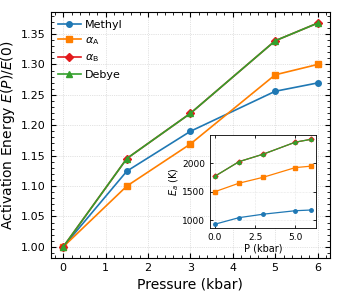

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import rcParams

# ======================================================
# JCP SINGLE-COLUMN STANDARD PARAMETERS
# ======================================================
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.weight': 'normal',       
    'axes.labelweight': 'normal',
    'axes.labelsize': 10,          # JCP standard label size
    'xtick.labelsize': 8,          # Clean tick sizes for small dimensions
    'ytick.labelsize': 8,
    'legend.fontsize': 8,          
    'axes.linewidth': 0.8,         # Professional frame thinness
    'lines.linewidth': 1.2,        # Thinner lines so curves don't bleed together
})

# =========================
# Data
# =========================
pressure = np.array([0, 1.5, 3, 5, 6])  # kbar

Ea_methyl = np.array([927.102, 1042.5272190969079, 1103.29610274308,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287, 1751.2476614923537,
                      1921.8082873682536, 1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                      2368.09349970613, 2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                     2368.09349970613, 2419.287235806273])

# =========================
# Normalized energies
# =========================
E_methyl_n = Ea_methyl / Ea_methyl[0]
E_alphaA_n = Ea_alphaA / Ea_alphaA[0]
E_alphaB_n = Ea_alphaB / Ea_alphaB[0]
E_debye_n  = Ea_debye  / Ea_debye[0]

# ======================================================
# FIGURE SETUP (Perfect JCP Single-Column Width)
# ======================================================
fig, ax = plt.subplots(figsize=(3.37, 3.0))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# High-contrast color & marker scheme
colors = {
    'methyl': '#1f78b4',
    'alphaA': '#ff7f00',
    'alphaB': '#e31a1c',
    'debye':  '#33a02c',
}
markers = {
    'methyl': 'o',
    'alphaA': 's',
    'alphaB': 'D',
    'debye':  '^',
}

lw = 1.2
ms = 4

# =========================
# Main plot: normalized Ea
# =========================
ax.plot(pressure, E_methyl_n, marker=markers['methyl'],
        color=colors['methyl'], lw=lw, ms=ms, label='I')

ax.plot(pressure, E_alphaA_n, marker=markers['alphaA'],
        color=colors['alphaA'], lw=lw, ms=ms, label=r'$\alpha_{\mathrm{A}}$')

ax.plot(pressure, E_alphaB_n, marker=markers['alphaB'],
        color=colors['alphaB'], lw=lw, ms=ms, label=r'$\alpha_{\mathrm{B}}$')

ax.plot(pressure, E_debye_n, marker=markers['debye'],
        color=colors['debye'], lw=lw, ms=ms, label='Debye')

ax.set_xlabel("Pressure (kbar)", labelpad=3)
ax.set_ylabel(r"Activation Energy $E(P)/E(0)$", labelpad=3)

# Inside ticks on all sides for publication style
ax.tick_params(direction='in', top=True, right=True, width=0.8, size=3.5)
ax.minorticks_on()
ax.tick_params(which='minor', direction='in', top=True, right=True, width=0.6, size=2.0)

ax.grid(True, which='major', linestyle=':', linewidth=0.5, alpha=0.7)
ax.legend(frameon=False, loc='upper left', handletextpad=0.4, borderaxespad=0.3)

# ======================================================
# INSET: Absolute Ea (Scaled cleanly for a small frame)
# ======================================================
ax_in = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc='lower left',
    bbox_to_anchor=(0.57, 0.12, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
ax_in.set_facecolor('white')

ax_in.plot(pressure, Ea_methyl, marker=markers['methyl'],
           color=colors['methyl'], lw=0.9, ms=2.5)

ax_in.plot(pressure, Ea_alphaA, marker=markers['alphaA'],
           color=colors['alphaA'], lw=0.9, ms=2.5)

ax_in.plot(pressure, Ea_alphaB, marker=markers['alphaB'],
           color=colors['alphaB'], lw=0.9, ms=2.5)

ax_in.plot(pressure, Ea_debye, marker=markers['debye'],
           color=colors['debye'], lw=0.9, ms=2.5)

ax_in.set_xlabel("P (kbar)", fontsize=7, labelpad=1)
ax_in.set_ylabel(r"$E_a$ (K)", fontsize=7, labelpad=1)

# Format inset ticks and spines down cleanly
ax_in.tick_params(labelsize=6.5, direction='in', top=True, right=True, width=0.6, size=2.5)
for spine in ax_in.spines.values():
    spine.set_linewidth(0.6)

ax_in.grid(True, linestyle=':', linewidth=0.4, alpha=0.6)

# ======================================================
# FINALIZE & EXPORT
# ======================================================
fig.subplots_adjust(left=0.15, right=0.98, bottom=0.14, top=0.96)

fig.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/Revised/figures/ActivationEnergy_norm_main22.pdf",
    dpi=600, bbox_inches='tight'
)
fig.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/Revised/figures/ActivationEnergy_norm_main22.png",
    dpi=600, bbox_inches='tight'
)

plt.show()

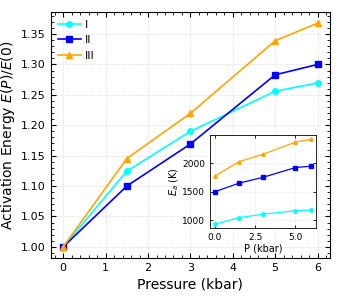

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import rcParams

# ======================================================
# JCP SINGLE-COLUMN STANDARD PARAMETERS
# ======================================================
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.weight': 'normal',       
    'axes.labelweight': 'normal',
    'axes.labelsize': 10,          # JCP standard label size
    'xtick.labelsize': 8,          # Clean tick sizes for small dimensions
    'ytick.labelsize': 8,
    'legend.fontsize': 8,          
    'axes.linewidth': 0.8,         # Professional frame thinness
    'lines.linewidth': 1.2,        # Thinner lines so curves don't bleed together
})

# =========================
# Data
# =========================
pressure = np.array([0, 1.5, 3, 5, 6])  # kbar

Ea_methyl = np.array([927.102, 1042.5272190969079, 1103.29610274308,
                      1164.3566397999396, 1177.0520823204824])

Ea_alphaA = np.array([1497.89, 1647.6450280130287, 1751.2476614923537,
                      1921.8082873682536, 1947.229495210424])

Ea_alphaB = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                      2368.09349970613, 2419.287235806273])

Ea_debye = np.array([1768.55, 2025.478584218733, 2156.9080577419845,
                     2368.09349970613, 2419.287235806273])

# =========================
# Normalized energies
# =========================
E_methyl_n = Ea_methyl / Ea_methyl[0]
E_alphaA_n = Ea_alphaA / Ea_alphaA[0]
E_alphaB_n = Ea_alphaB / Ea_alphaB[0]
E_debye_n  = Ea_debye  / Ea_debye[0]

# ======================================================
# FIGURE SETUP (Perfect JCP Single-Column Width)
# ======================================================
fig, ax = plt.subplots(figsize=(3.37, 3.0))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# High-contrast color & marker scheme
colors = {
    'methyl': 'cyan',
    'alphaA': 'blue',
    'alphaB': '#e31a1c',
    'debye':  'orange',
}
markers = {
    'methyl': 'o',
    'alphaA': 's',
    'alphaB': 'D',
    'debye':  '^',
}

lw = 1.2
ms = 4

# =========================
# Main plot: normalized Ea
# =========================
ax.plot(pressure, E_methyl_n, marker=markers['methyl'],
        color=colors['methyl'], lw=lw, ms=ms, label='I')

ax.plot(pressure, E_alphaA_n, marker=markers['alphaA'],
        color=colors['alphaA'], lw=lw, ms=ms, label=r'II')

# ax.plot(pressure, E_alphaB_n, marker=markers['alphaB'],
#         color=colors['alphaB'], lw=lw, ms=ms, label=r'$\alpha_{\mathrm{B}}$')

ax.plot(pressure, E_debye_n, marker=markers['debye'],
        color=colors['debye'], lw=lw, ms=ms, label='III')

ax.set_xlabel("Pressure (kbar)", labelpad=3)
ax.set_ylabel(r"Activation Energy $E(P)/E(0)$", labelpad=3)

# Inside ticks on all sides for publication style
ax.tick_params(direction='in', top=True, right=True, width=0.8, size=3.5)
ax.minorticks_on()
ax.tick_params(which='minor', direction='in', top=True, right=True, width=0.6, size=2.0)

ax.grid(True, which='major', linestyle=':', linewidth=0.5, alpha=0.7)
ax.legend(frameon=False, loc='upper left', handletextpad=0.4, borderaxespad=0.3)

# ======================================================
# INSET: Absolute Ea (Scaled cleanly for a small frame)
# ======================================================
ax_in = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc='lower left',
    bbox_to_anchor=(0.57, 0.12, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
ax_in.set_facecolor('white')

ax_in.plot(pressure, Ea_methyl, marker=markers['methyl'],
           color=colors['methyl'], lw=0.9, ms=2.5)

ax_in.plot(pressure, Ea_alphaA, marker=markers['alphaA'],
           color=colors['alphaA'], lw=0.9, ms=2.5)

# ax_in.plot(pressure, Ea_alphaB, marker=markers['alphaB'],
#            color=colors['alphaB'], lw=0.9, ms=2.5)

ax_in.plot(pressure, Ea_debye, marker=markers['debye'],
           color=colors['debye'], lw=0.9, ms=2.5)

ax_in.set_xlabel("P (kbar)", fontsize=7, labelpad=1)
ax_in.set_ylabel(r"$E_a$ (K)", fontsize=7, labelpad=1)

# Format inset ticks and spines down cleanly
ax_in.tick_params(labelsize=6.5, direction='in', top=True, right=True, width=0.6, size=2.5)
for spine in ax_in.spines.values():
    spine.set_linewidth(0.6)

ax_in.grid(True, linestyle=':', linewidth=0.4, alpha=0.6)

# ======================================================
# FINALIZE & EXPORT
# ======================================================
fig.subplots_adjust(left=0.15, right=0.98, bottom=0.14, top=0.96)

fig.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/Revised/figures/ActivationEnergy_norm_main33.pdf",
    dpi=600, bbox_inches='tight'
)
fig.savefig(
    "/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/PC_propanol/Revised/figures/ActivationEnergy_norm_main33.png",
    dpi=600, bbox_inches='tight'
)

plt.show()